# Multiple annotated autoencoder comparison
Every comparison automatically includes all configured models.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

# set cwd to repository root
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / 'pyproject.toml').is_file())
os.chdir(repository_root)

In [14]:
PROJECT_PATH = 'workspace'
DEFAULT_IMAGE = 'kidney-pilot-v2'
MODEL_NAMES = ['kidney-annotation-autoencoder', 'kidney-annotation-mse-autoencoder']
HEAD_NAME = 'molecule_primary'
BATCH_SIZE = 8
RANDOM_SEED = 1912

In [4]:
from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis import AutoencoderMultiAnalysis
from msi_autoencoder_wrapper.visualization import VisualizationTheme
wrapper = MSIAutoEncoderWrapper(project_path=PROJECT_PATH)
wrapper.workspace.set_default_image_path(DEFAULT_IMAGE)
wrapper.load_configuration("kidney-annotation-autoencoder")


theme = VisualizationTheme(model_overrides={MODEL_NAMES[0]: '#2563EB', MODEL_NAMES[1]: '#F97316'})
analysis = AutoencoderMultiAnalysis(wrapper, MODEL_NAMES, theme=theme)

retain = {
    'inputs',
    'reconstructions',
    'targets',
}
analysis.estimate_prepare_size(retain=retain)


2026-07-30 10:09:10,863 | INFO     | msi_autoencoder_wrapper.core.wrapper:71 | MSIAutoEncoderWrapper: Anchoring processing device state: cuda
2026-07-30 10:09:10,864 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.
2026-07-30 10:09:10,867 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.
2026-07-30 10:09:10,868 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.
2026-07-30 10:09:10,870 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.
2026-07-30 10:09:10,873 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 13 implementati

PreparationEstimate(sample_count=5959, retained_bytes={'kidney-annotation-autoencoder:spectrum_ids': 47672, 'kidney-annotation-autoencoder:pixel_metrics': 333704, 'kidney-annotation-autoencoder:feature_metrics': 2640168, 'inputs': 2622126852, 'kidney-annotation-autoencoder:reconstructions': 2622126852, 'targets': 524392, 'target_masks': 5959, 'kidney-annotation-mse-autoencoder:spectrum_ids': 47672, 'kidney-annotation-mse-autoencoder:pixel_metrics': 333704, 'kidney-annotation-mse-autoencoder:feature_metrics': 2640168, 'kidney-annotation-mse-autoencoder:reconstructions': 2622126852})

In [5]:
prepared = analysis.prepare(retain=retain, batch_size=BATCH_SIZE)
mass_axis = wrapper.active_context.binner.GetXAxis()

2026-07-30 10:10:25,637 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.base:219 | Preparing analysis for model 'kidney-annotation-autoencoder' over 5959 spectra.
2026-07-30 10:11:31,281 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.base:219 | Preparing analysis for model 'kidney-annotation-mse-autoencoder' over 5959 spectra.


## Automatic metric comparison

In [6]:
comparison = pd.DataFrame(analysis.reconstruction.compare_metrics(
    metrics=['mse', 'mae', 'masserstein', 'cosine_similarity', 'spectral_angle', 'tic_error'],
))
comparison

,metric,model,rank,count,mean,std,min,q25,median,q75,max
0,mse,kidney-annotation-mse-autoencoder,1,5959.0,0.000001,9.243051e-07,9.860626e-07,0.000001,0.000001,0.000001,0.000035
1,mse,kidney-annotation-autoencoder,2,5959.0,5.039171,5.393511e+00,5.696233e-01,0.569721,0.569779,11.547927,11.547927
2,mae,kidney-annotation-mse-autoencoder,1,5959.0,0.000510,1.293209e-04,4.513735e-04,0.000478,0.000509,0.000511,0.004140
3,mae,kidney-annotation-autoencoder,2,5959.0,0.311554,2.809214e-01,7.870570e-02,0.078733,0.078754,0.650563,0.650563
4,masserstein,kidney-annotation-mse-autoencoder,1,5959.0,0.482620,9.333650e-03,4.712575e-01,0.474202,0.476071,0.493638,0.493638
5,masserstein,kidney-annotation-autoencoder,2,5959.0,0.490298,1.517653e-04,4.900196e-01,0.490173,0.490187,0.490480,0.490480
6,cosine_similarity,kidney-annotation-mse-autoencoder,1,5959.0,0.110532,9.278061e-02,0.000000e+00,0.000000,0.184633,0.191661,0.199435
7,cosine_similarity,kidney-annotation-autoencoder,2,5959.0,0.000924,7.726323e-04,0.000000e+00,0.000000,0.001458,0.001565,0.002766
8,spectral_angle,kidney-annotation-mse-autoencoder,1,5959.0,1.459596,9.335147e-02,1.370015e+00,1.377942,1.385098,1.570796,1.570796
9,spectral_angle,kidney-annotation-autoencoder,2,5959.0,1.569872,7.726326e-04,1.568030e+00,1.569231,1.569339,1.570796,1.570796


(<Figure size 1440x840 with 1 Axes>,
 <Axes: title={'center': 'spectral_angle distribution'}, xlabel='spectral_angle', ylabel='Density'>)

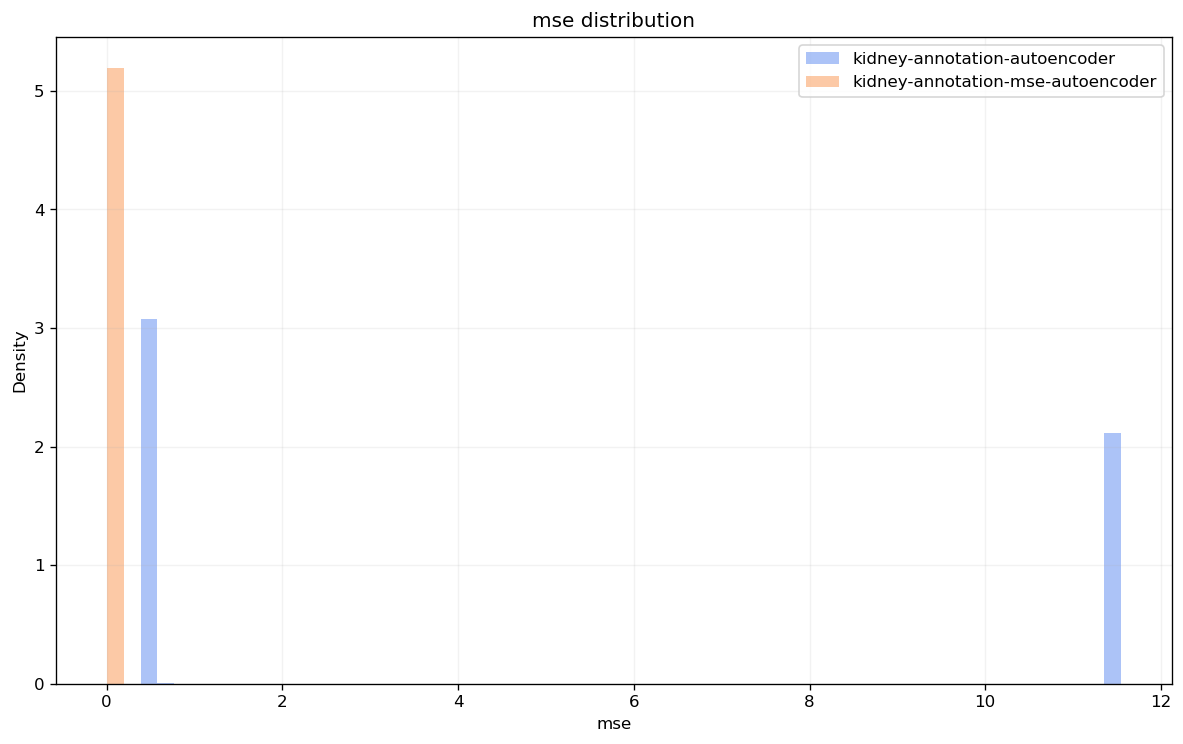

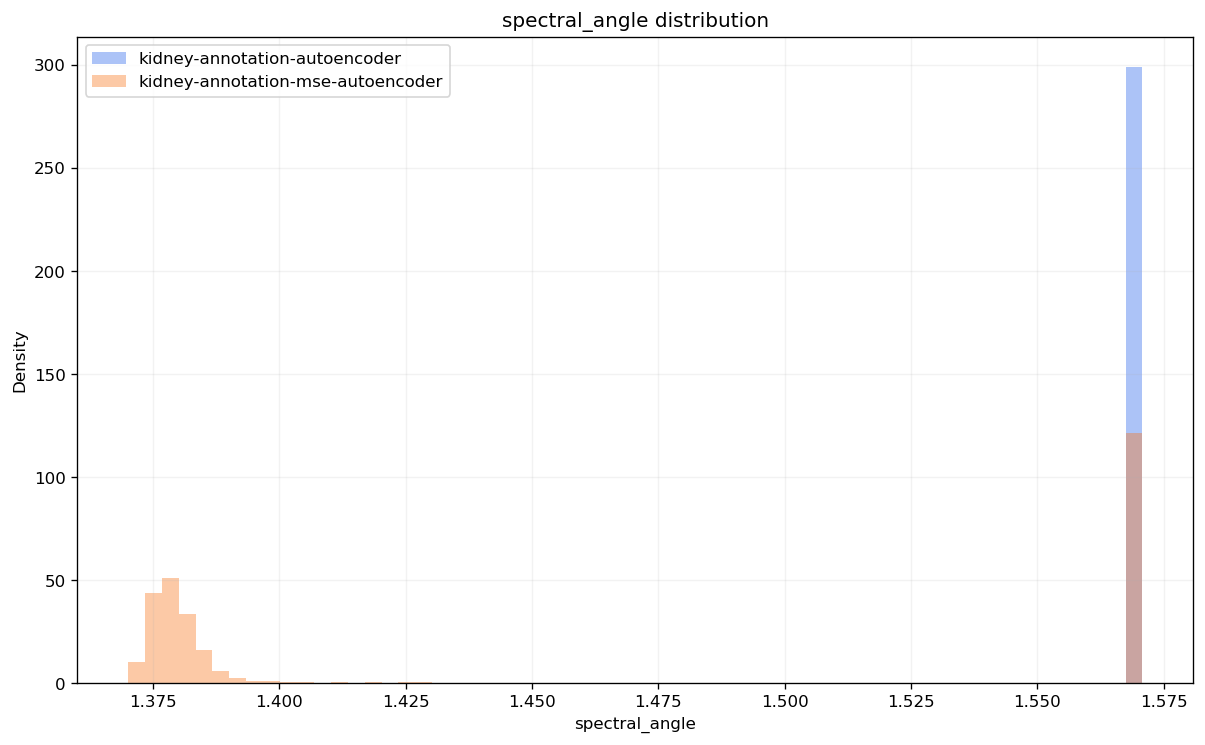

In [7]:
analysis.reconstruction.plot_distribution('mse')
analysis.reconstruction.plot_distribution('spectral_angle')

(<Figure size 840x1800 with 6 Axes>,
 array([<Axes: title={'left': 'annotation availability'}>,
        <Axes: title={'left': 'kidney-annotation-autoencoder: mse'}>,
        <Axes: title={'left': 'kidney-annotation-mse-autoencoder: mse'}>],
       dtype=object))

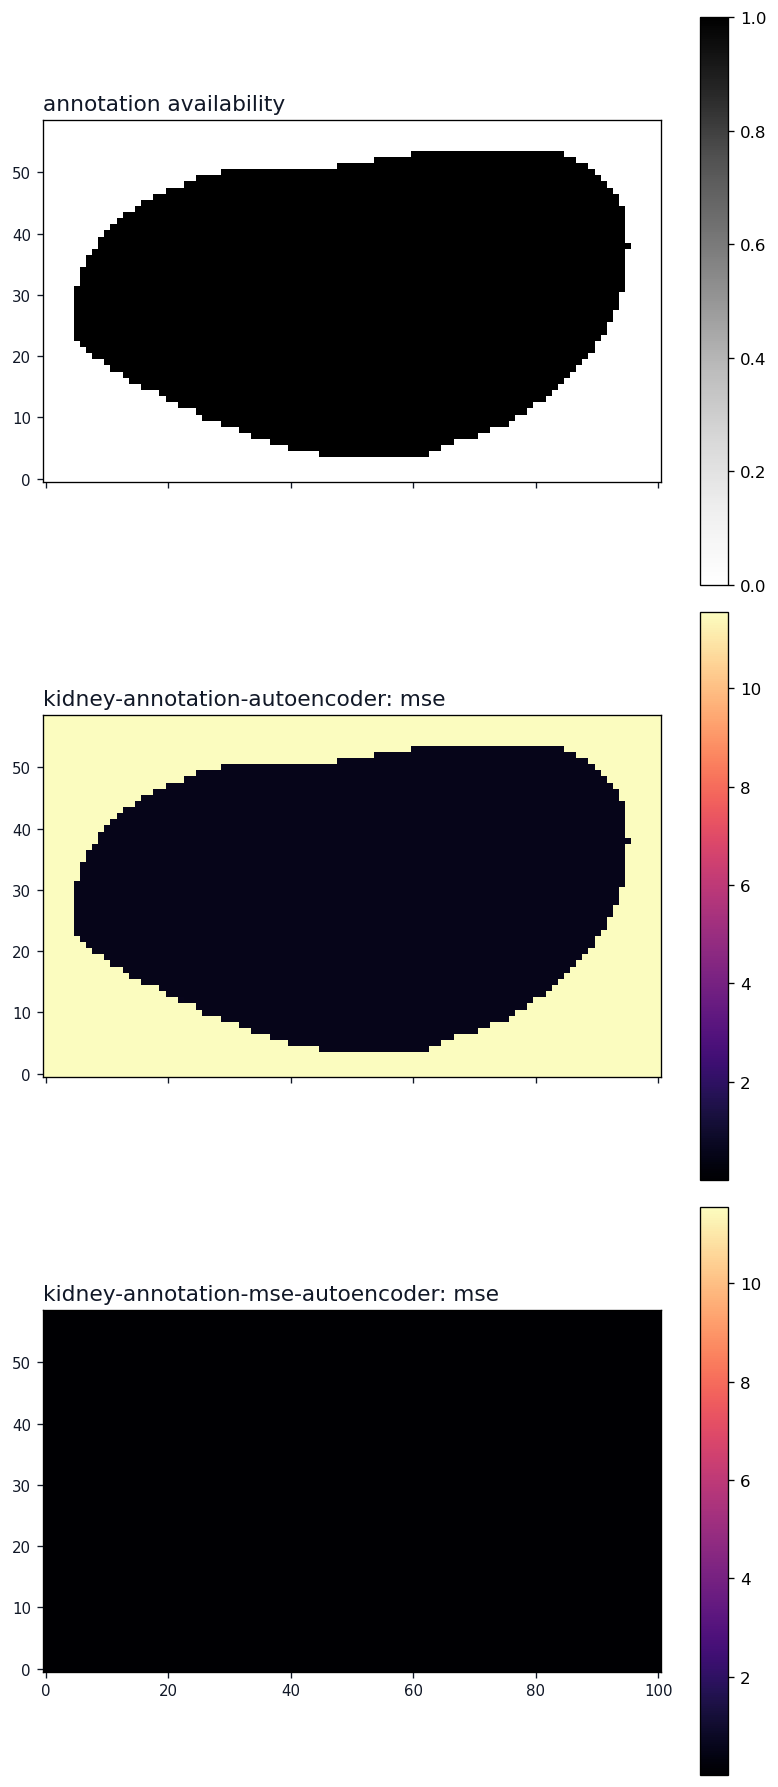

In [8]:
analysis.reconstruction.plot_error_images('mse', target_field='molecule', show_annotation_mask=True)

## Populations selected independently by every model

dict_keys(['kidney-annotation-autoencoder', 'kidney-annotation-mse-autoencoder'])

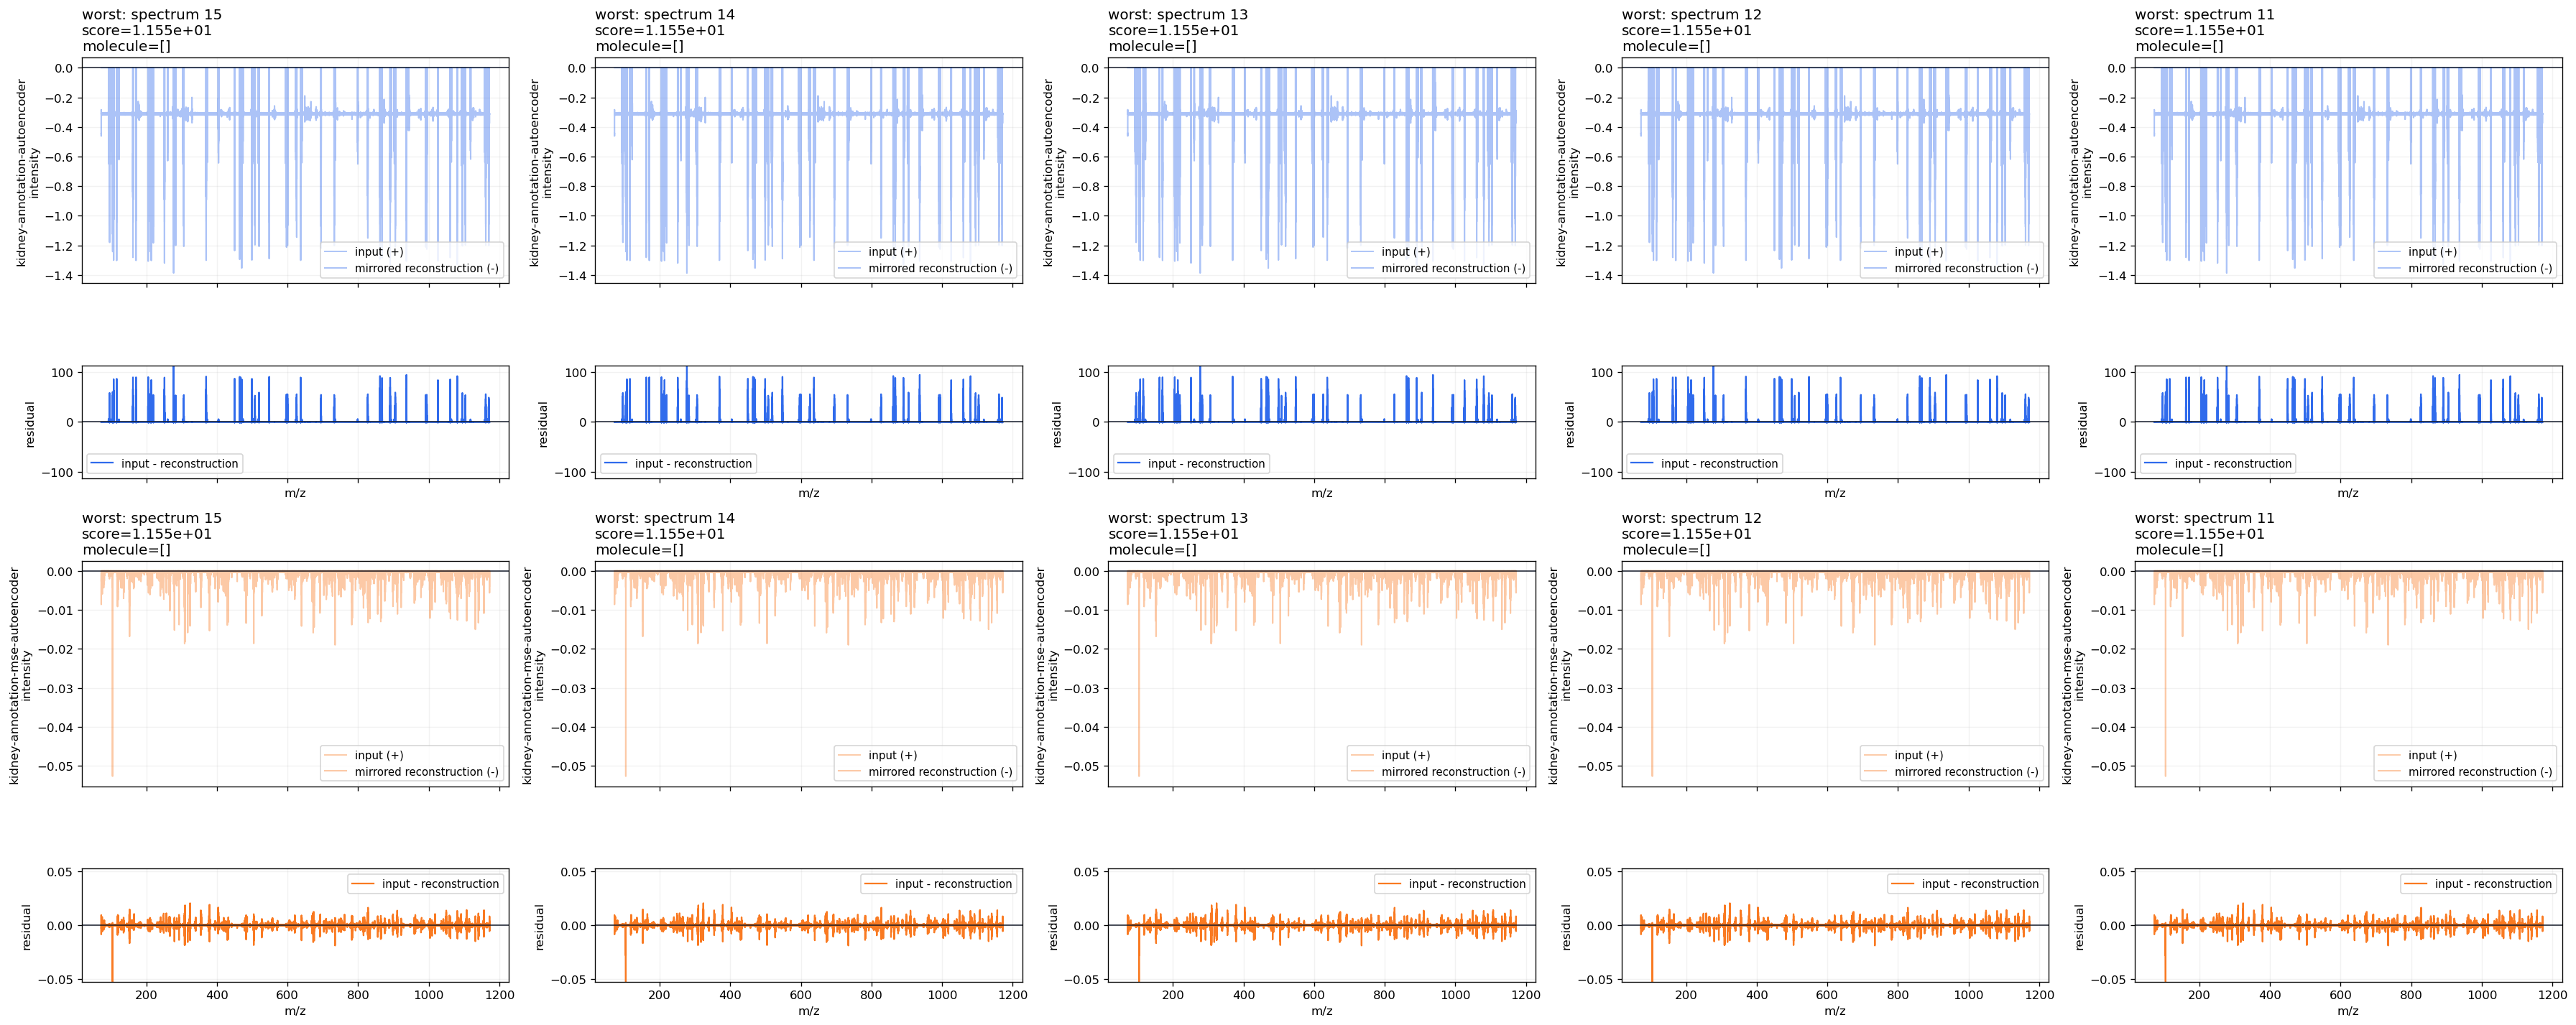

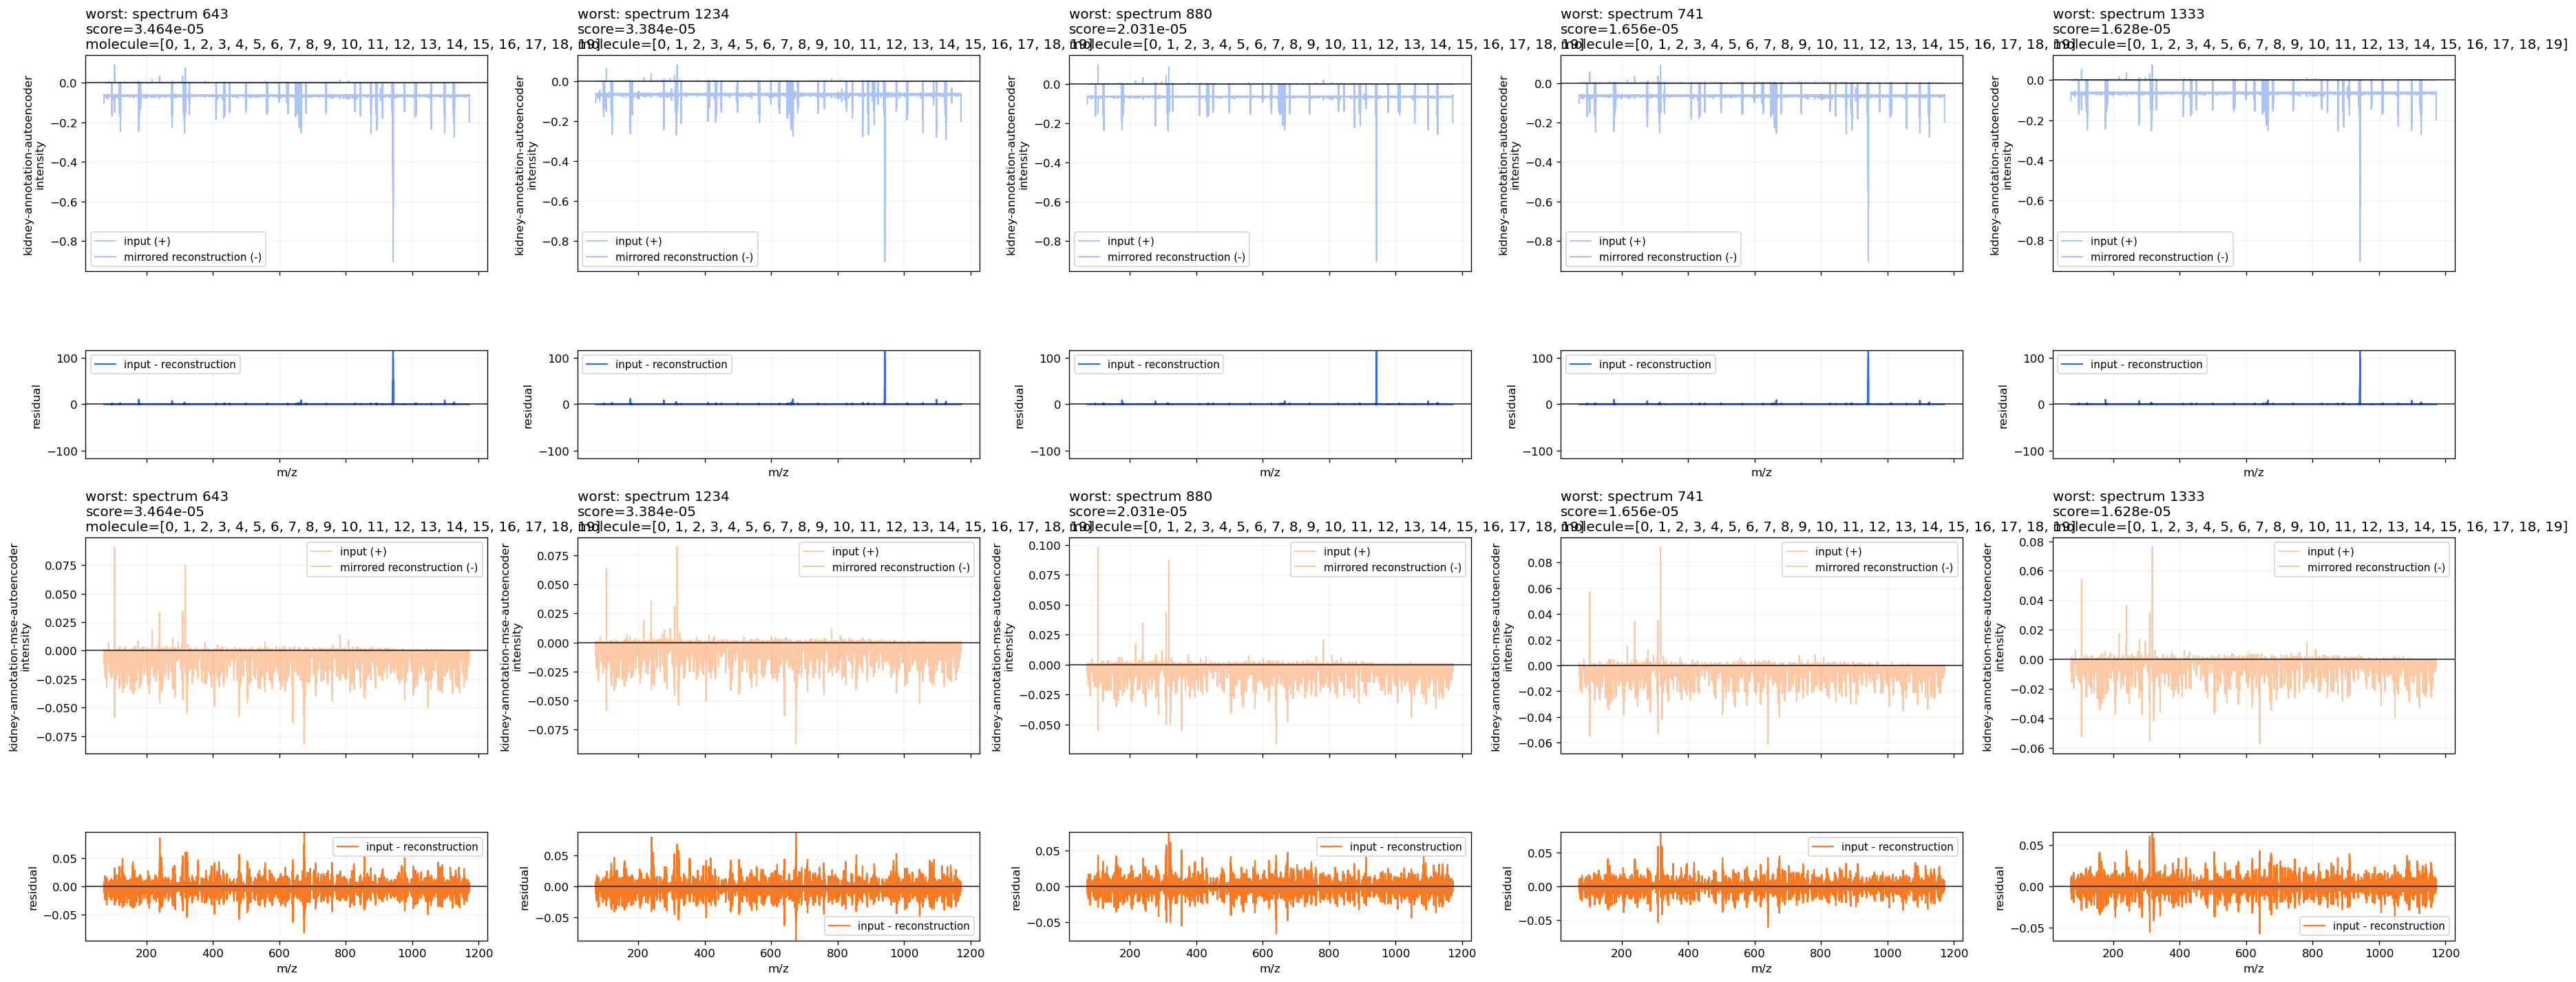

In [9]:
worst_populations = analysis.reconstruction.plot_selected_spectra_comparison(
    metric='mse', selection='worst', count=5, selection_models=MODEL_NAMES,
)
worst_populations.keys()

,model,rank,feature_index,mz,mean,median,lower_quantile,upper_quantile
0,kidney-annotation-autoencoder,1,87039,942.47704,8003.706156,13499.613163,0.015831,13500.153899
1,kidney-annotation-autoencoder,2,87066,942.74704,5687.838141,9593.478530,0.077602,9593.635458
2,kidney-annotation-autoencoder,3,20511,277.19704,5277.944306,2.042860,1.479463,12961.104693
3,kidney-annotation-autoencoder,4,87042,942.50704,5174.660758,8727.934683,0.010017,8728.181301
4,kidney-annotation-autoencoder,5,20523,277.31704,4195.186485,1.242551,0.845865,10302.703794
5,kidney-annotation-autoencoder,6,86463,936.71704,3678.093831,0.004088,0.004088,9034.520484
6,kidney-annotation-autoencoder,7,78975,861.83704,3502.477400,0.004088,0.004088,8603.152670
7,kidney-annotation-autoencoder,8,100863,1080.71704,3485.254962,0.004088,0.004088,8560.849083
8,kidney-annotation-autoencoder,9,29727,369.35704,3430.993194,0.004088,0.004088,8427.565539
9,kidney-annotation-autoencoder,10,39231,464.39704,3387.151831,0.004088,0.004088,8319.877708


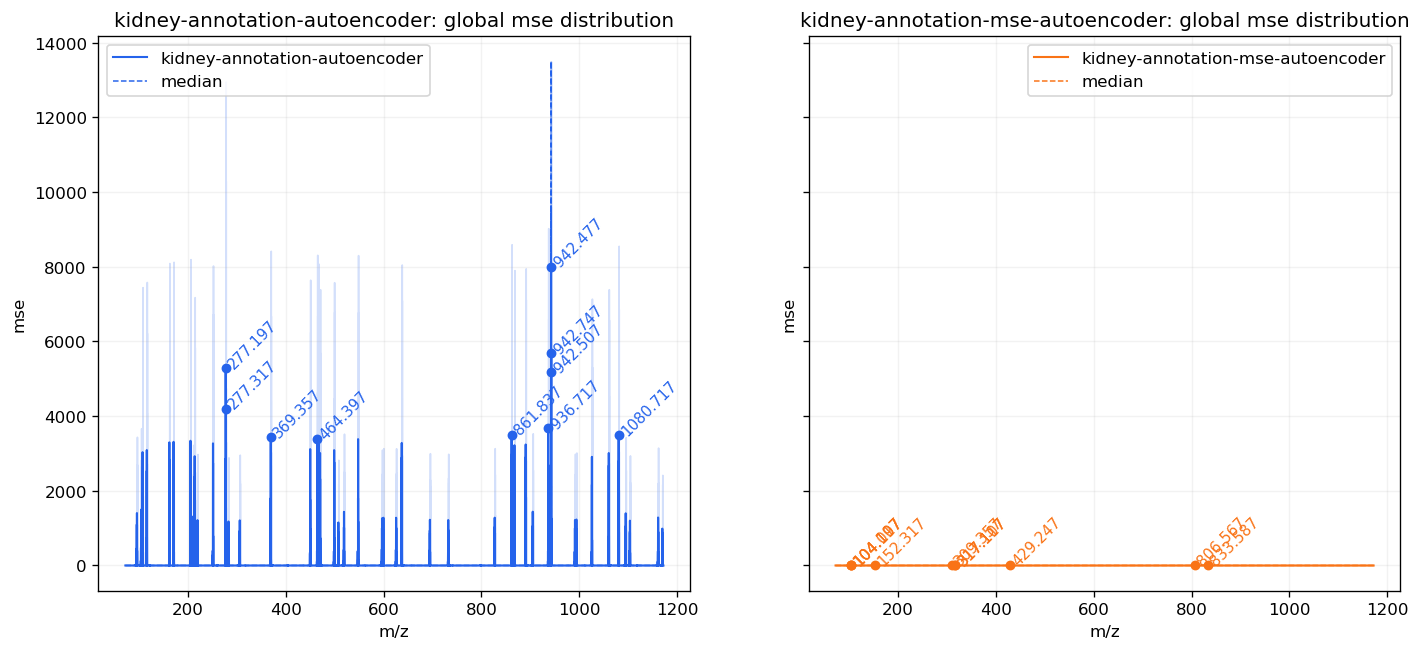

In [10]:
worst_features = pd.DataFrame(analysis.reconstruction.rank_features(metric='mse', top_n=10))
analysis.reconstruction.plot_feature_error_overview(metric='mse', quantiles=(0.05, 0.95), top_n=10)
worst_features

## Shared input/labels and model ion reconstructions

(<Figure size 1920x1200 with 12 Axes>,
 array([[<Axes: title={'left': 'input: 942.47704 m/z'}>,
         <Axes: title={'left': 'kidney-annotation-autoencoder: reconstruction'}>,
         <Axes: title={'left': 'kidney-annotation-autoencoder: residual'}>],
        [<Axes: title={'left': 'annotation availability'}>,
         <Axes: title={'left': 'kidney-annotation-mse-autoencoder: reconstruction'}>,
         <Axes: title={'left': 'kidney-annotation-mse-autoencoder: residual'}>]],
       dtype=object))

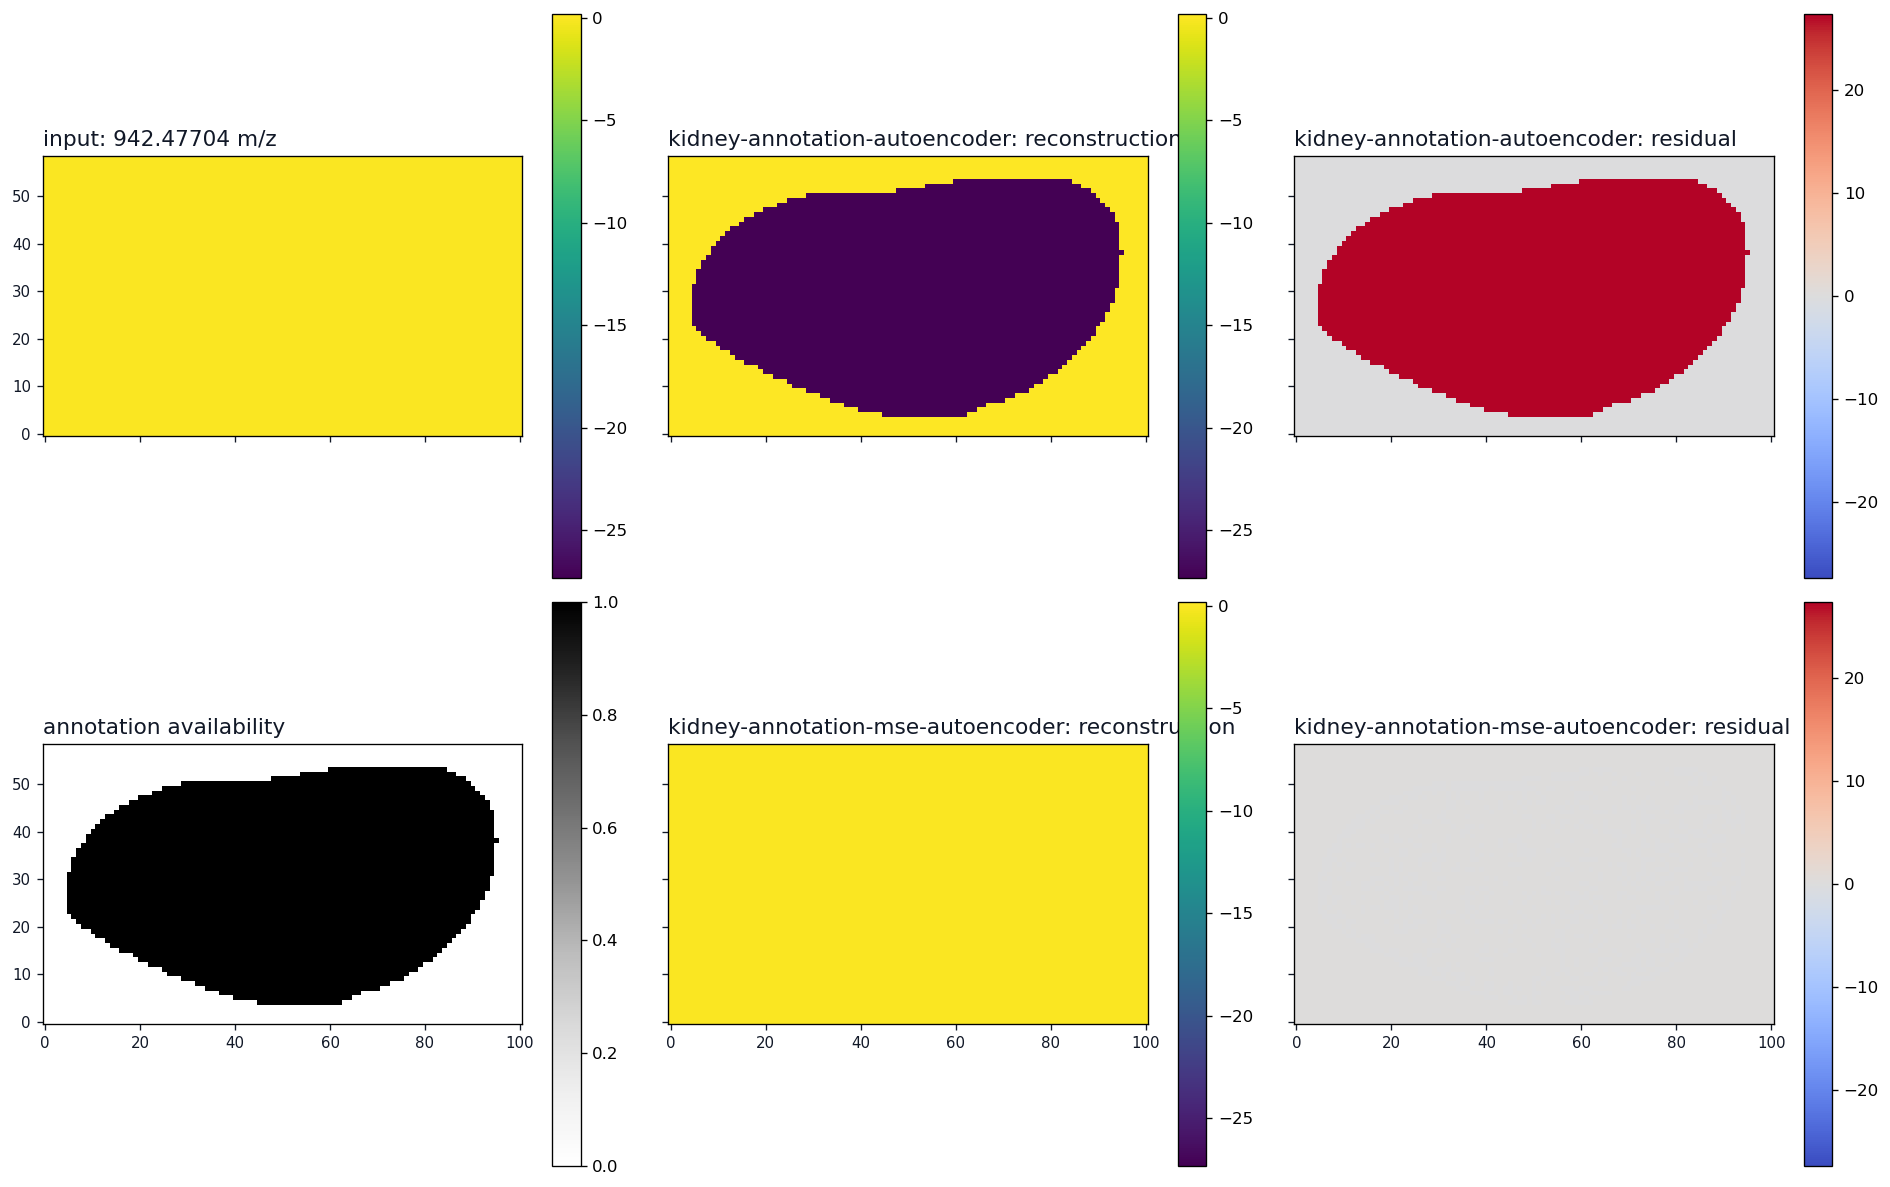

In [11]:
first_model = prepared.for_model(MODEL_NAMES[0])
selected_mz = float(mass_axis[int(np.argmax(first_model.feature_metrics['feature_mse']))])
analysis.reconstruction.plot_ion_images(selected_mz, tolerance=0.02, target_field='molecule')

In [ ]:
viewer = analysis.reconstruction.ion_viewer(tolerance=0.02, target_field='molecule')
viewer.widget(initial_index=int(np.argmin(np.abs(mass_axis - selected_mz))))

## Molecules in PCA and t-SNE space

In [21]:
# here we calculate values needed for classifications analysis
# REMARK: important is that we DO NOT calcaulate everything at once. It can break computer as it uses much memory
prepared = analysis.prepare(
    retain={
        'head_outputs',
        'targets',
        "latents"
        
    },
    batch_size=8,
    loader_options={
        'num_workers': 0,
        'pin_memory': False,
    },
)

2026-07-30 11:01:22,969 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.base:219 | Preparing analysis for model 'kidney-annotation-autoencoder' over 5959 spectra.
2026-07-30 11:02:13,317 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.base:219 | Preparing analysis for model 'kidney-annotation-mse-autoencoder' over 5959 spectra.


(<Figure size 720x1200 with 2 Axes>,
 array([[<Axes: title={'center': 'kidney-annotation-autoencoder: PCA, all molecules'}, xlabel='Component 1', ylabel='Component 2'>],
        [<Axes: title={'center': 'kidney-annotation-mse-autoencoder: PCA, all molecules'}, xlabel='Component 1', ylabel='Component 2'>]],
       dtype=object))

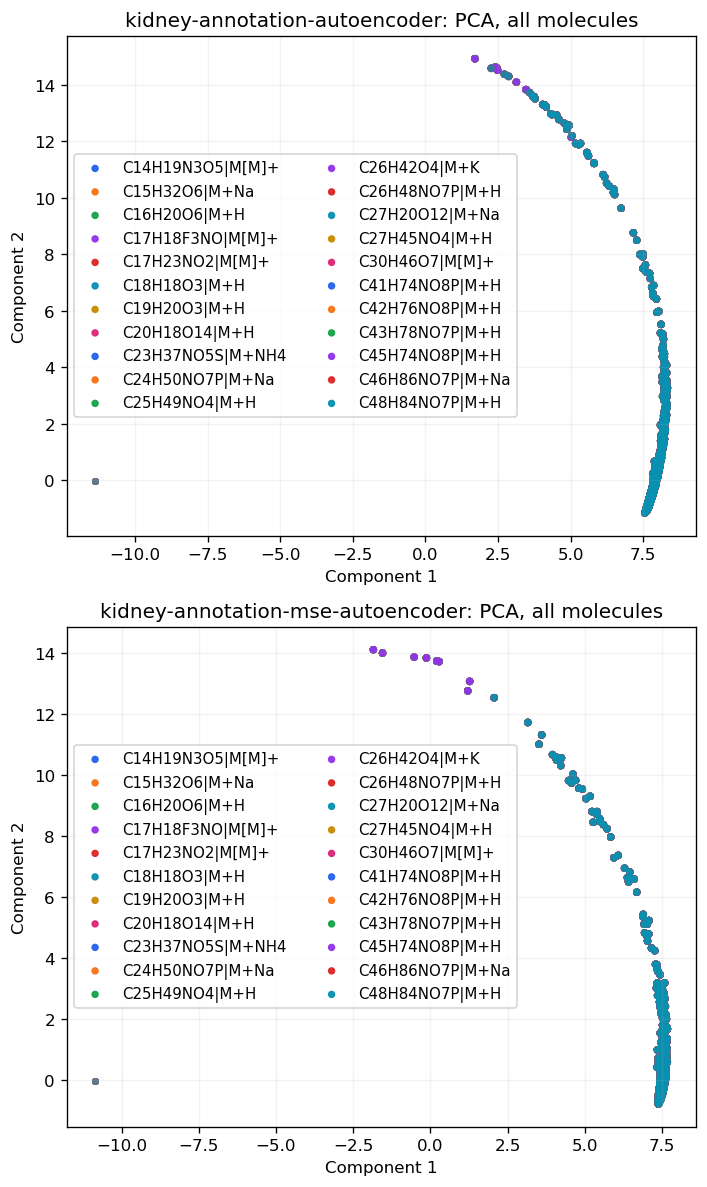

In [22]:
analysis.latent.plot_target_projection('molecule', method='pca', mode='overlay', head_name=HEAD_NAME, random_seed=RANDOM_SEED)

{1: (<Figure size 4320x1200 with 12 Axes>,
  array([[<Axes: title={'center': 'kidney-annotation-autoencoder: C14H19N3O5|M[M]+\ngreen=correct, red=incorrect'}, xlabel='Component 1', ylabel='Component 2'>,
          <Axes: title={'center': 'kidney-annotation-autoencoder: C15H32O6|M+Na\ngreen=correct, red=incorrect'}, xlabel='Component 1', ylabel='Component 2'>,
          <Axes: title={'center': 'kidney-annotation-autoencoder: C16H20O6|M+H\ngreen=correct, red=incorrect'}, xlabel='Component 1', ylabel='Component 2'>,
          <Axes: title={'center': 'kidney-annotation-autoencoder: C17H18F3NO|M[M]+\ngreen=correct, red=incorrect'}, xlabel='Component 1', ylabel='Component 2'>,
          <Axes: title={'center': 'kidney-annotation-autoencoder: C17H23NO2|M[M]+\ngreen=correct, red=incorrect'}, xlabel='Component 1', ylabel='Component 2'>,
          <Axes: title={'center': 'kidney-annotation-autoencoder: C18H18O3|M+H\ngreen=correct, red=incorrect'}, xlabel='Component 1', ylabel='Component 2'>],
  

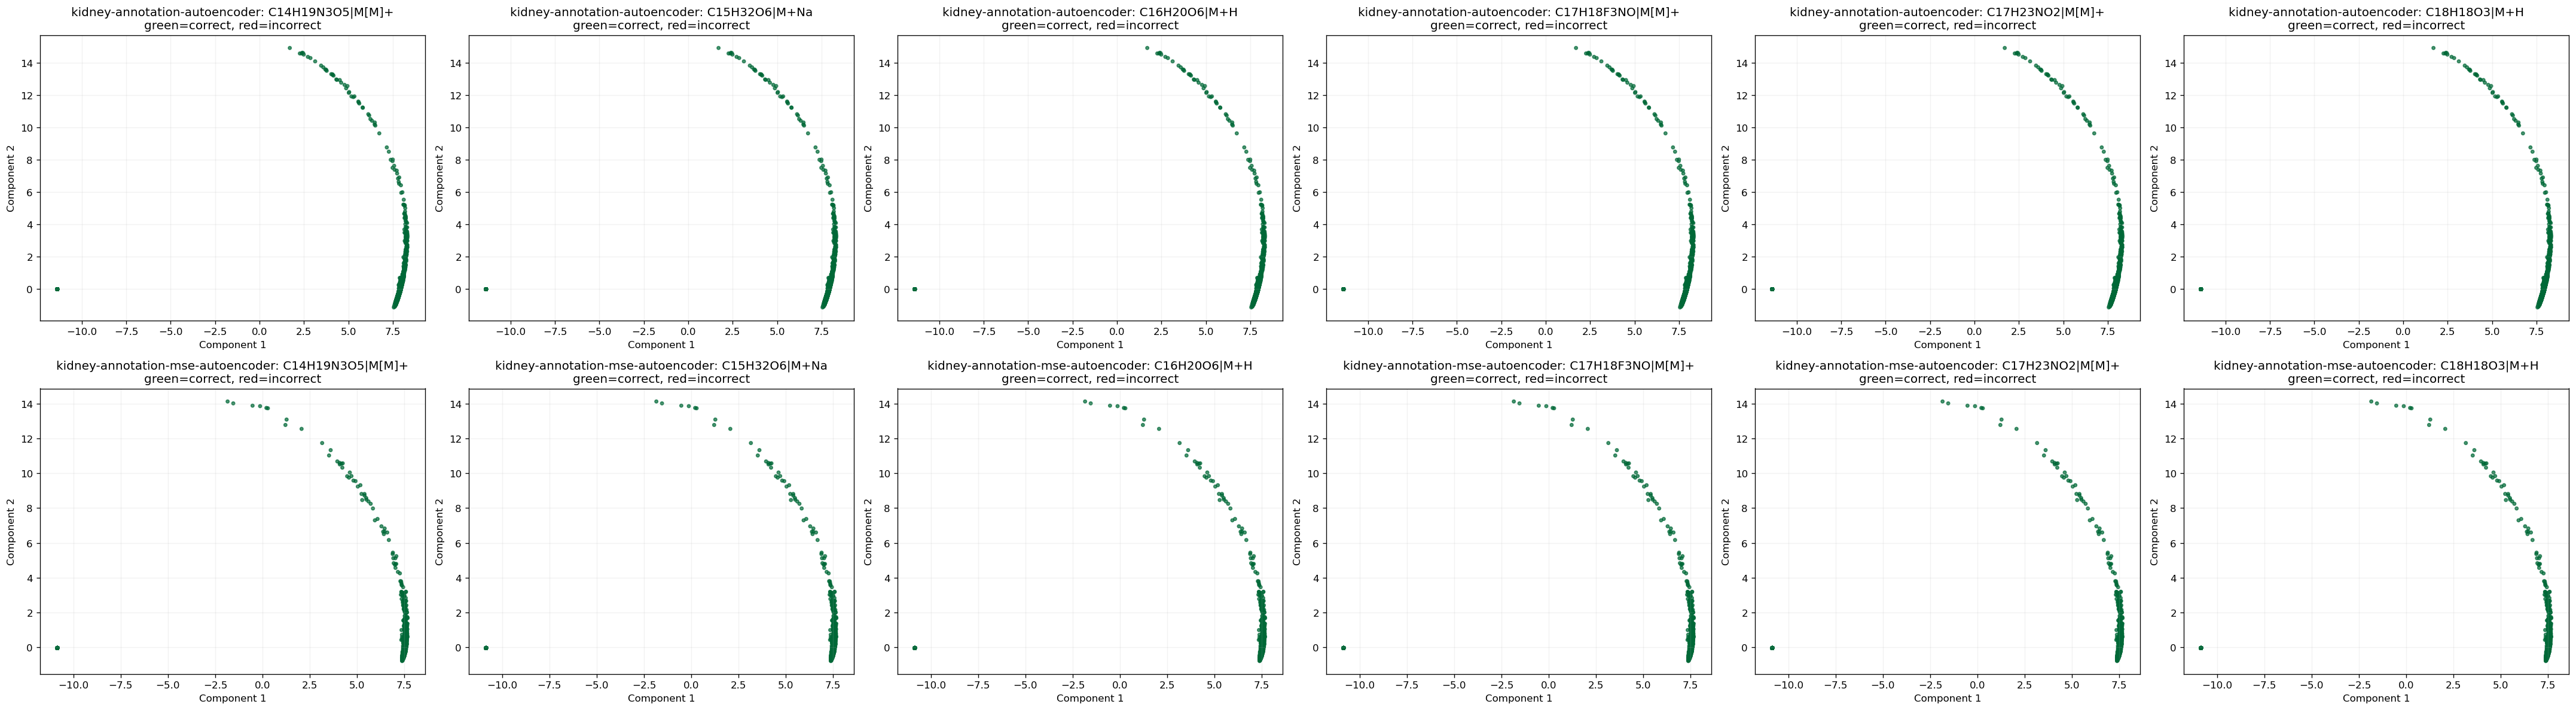

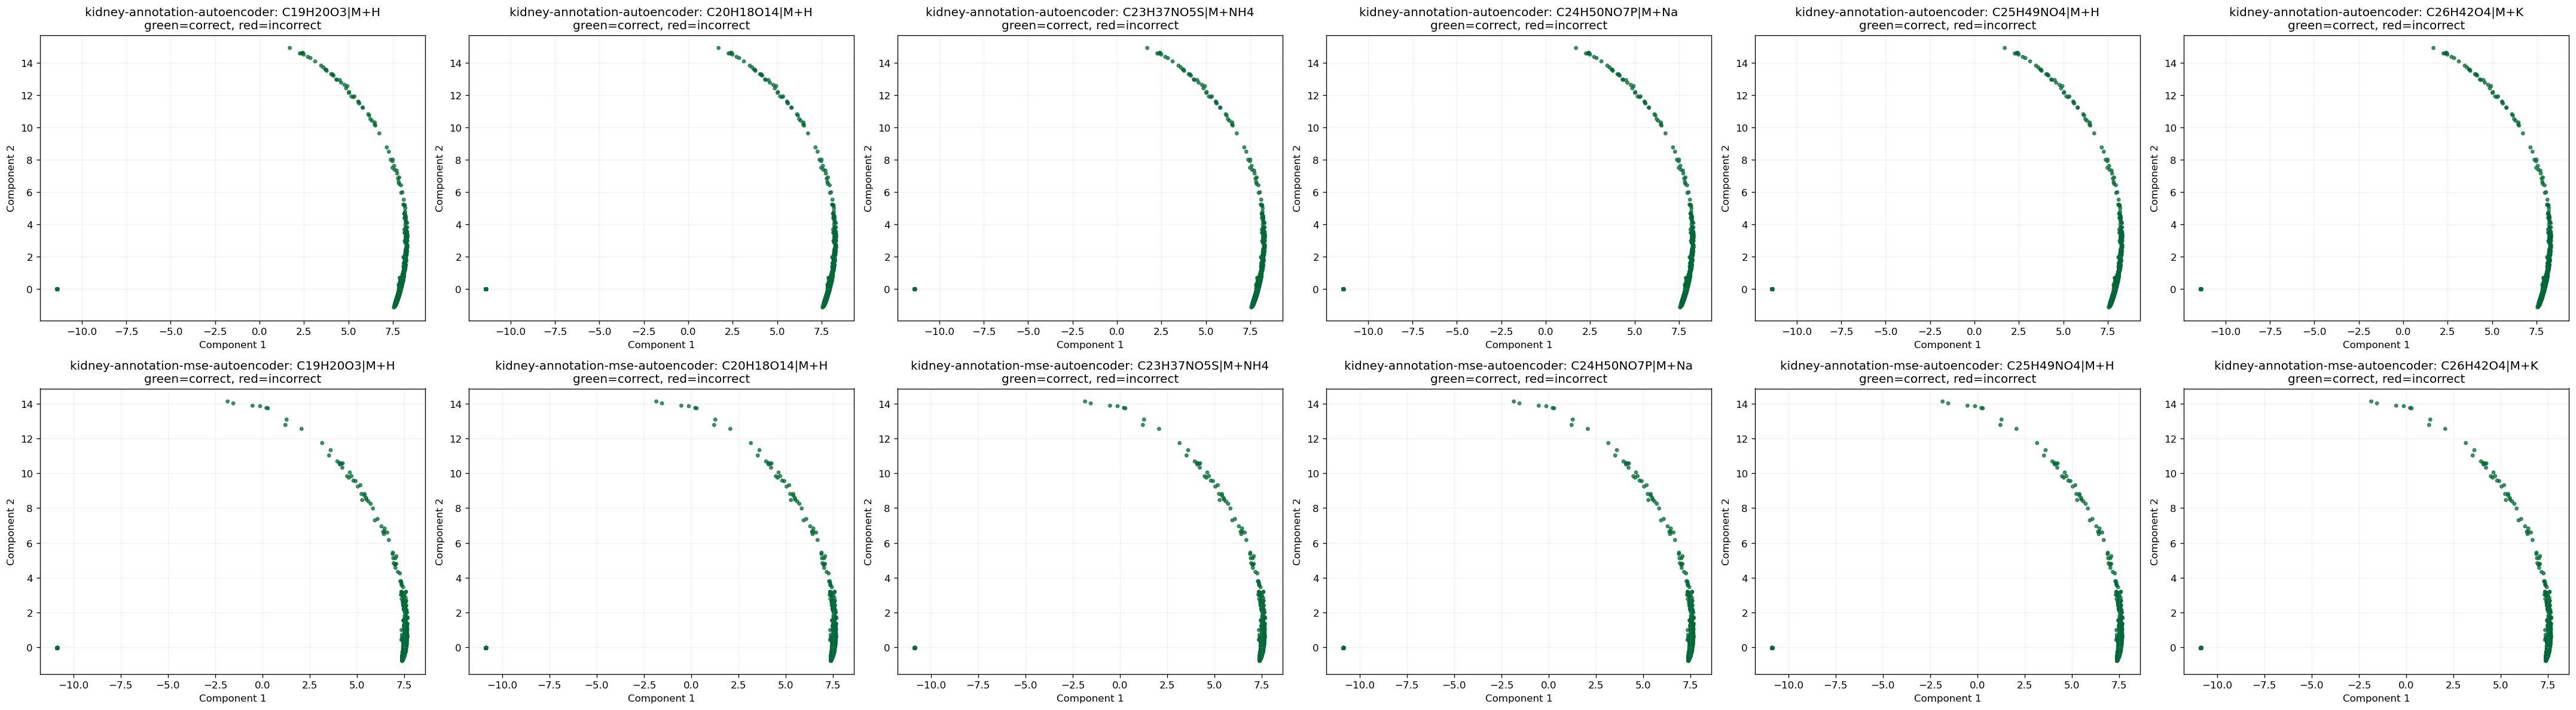

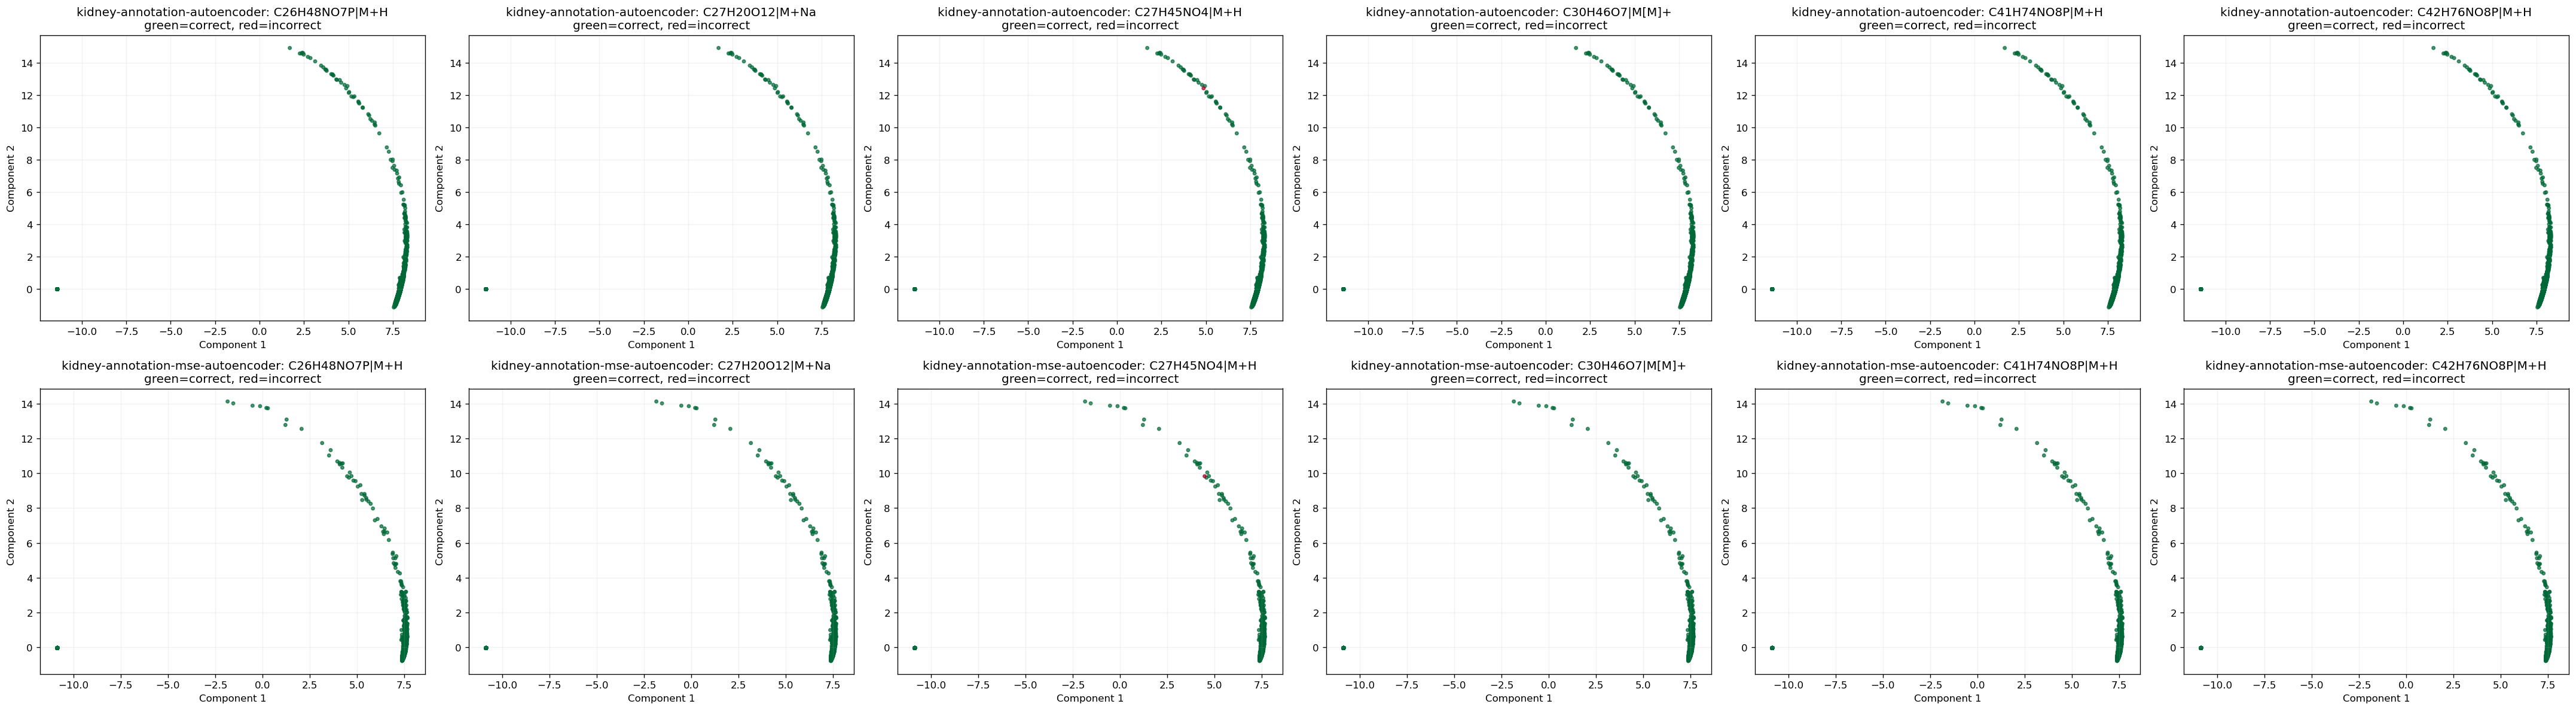

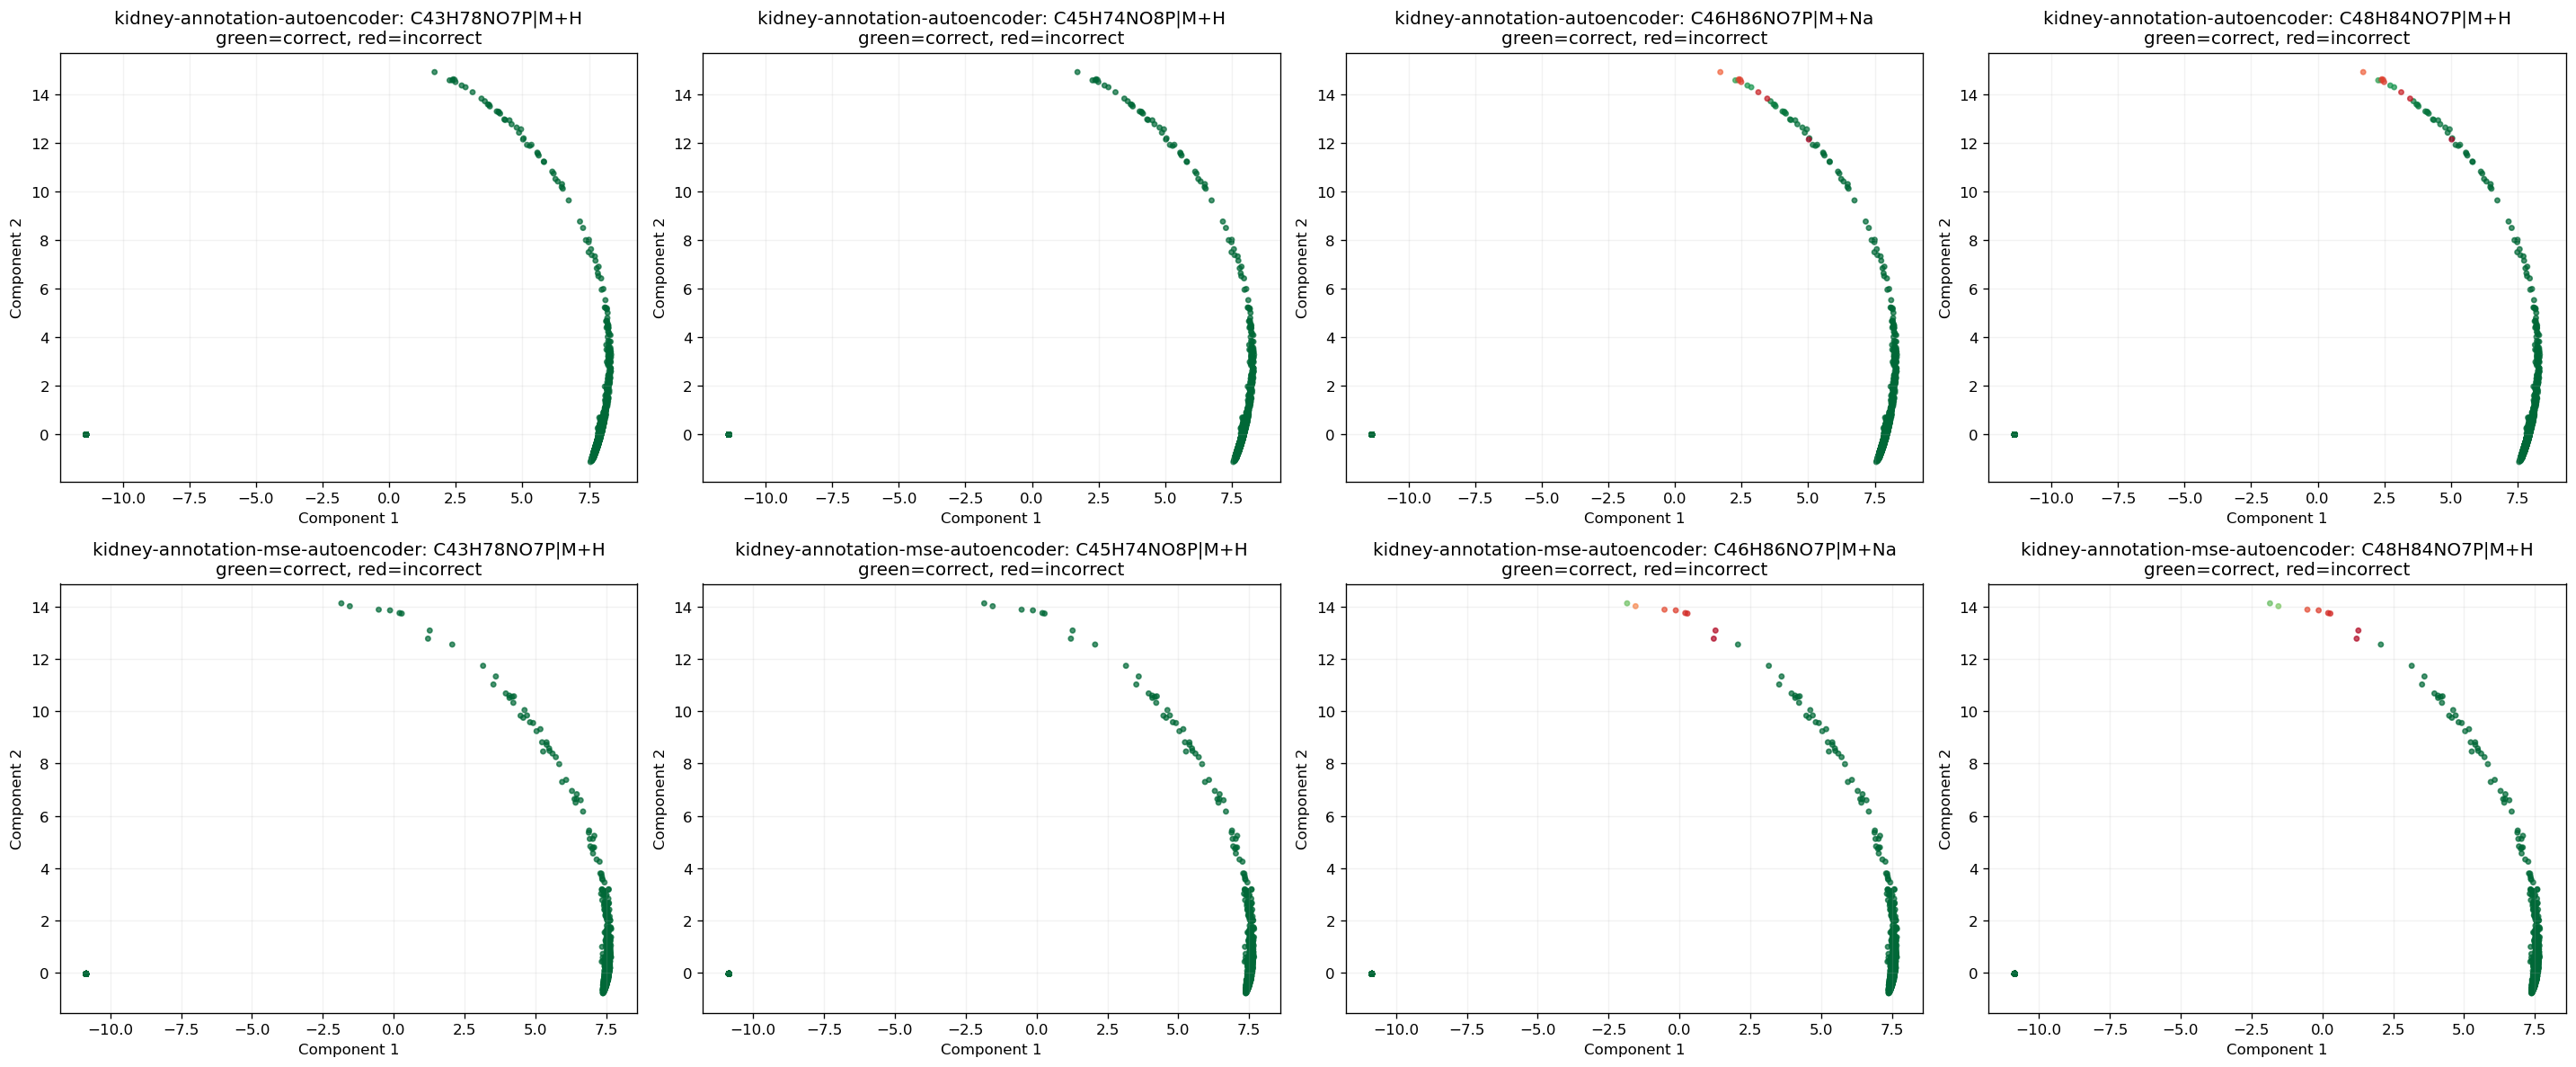

In [23]:
analysis.latent.plot_target_projection('molecule', method='pca', mode='panels', head_name=HEAD_NAME, random_seed=RANDOM_SEED)

## Per-class head comparison

{'kidney-annotation-autoencoder':     class_index  positive_samples  precision  recall        f1  \
 0           0.0            3533.0   1.000000     1.0  1.000000   
 1           1.0            3533.0   1.000000     1.0  1.000000   
 2           2.0            3533.0   1.000000     1.0  1.000000   
 3           3.0            3533.0   1.000000     1.0  1.000000   
 4           4.0            3533.0   1.000000     1.0  1.000000   
 5           5.0            3533.0   1.000000     1.0  1.000000   
 6           6.0            3533.0   1.000000     1.0  1.000000   
 7           7.0            3533.0   1.000000     1.0  1.000000   
 8           8.0            3533.0   1.000000     1.0  1.000000   
 9           9.0            3533.0   1.000000     1.0  1.000000   
 10         10.0            3533.0   1.000000     1.0  1.000000   
 11         11.0            3533.0   1.000000     1.0  1.000000   
 12         12.0            3533.0   1.000000     1.0  1.000000   
 13         13.0            3

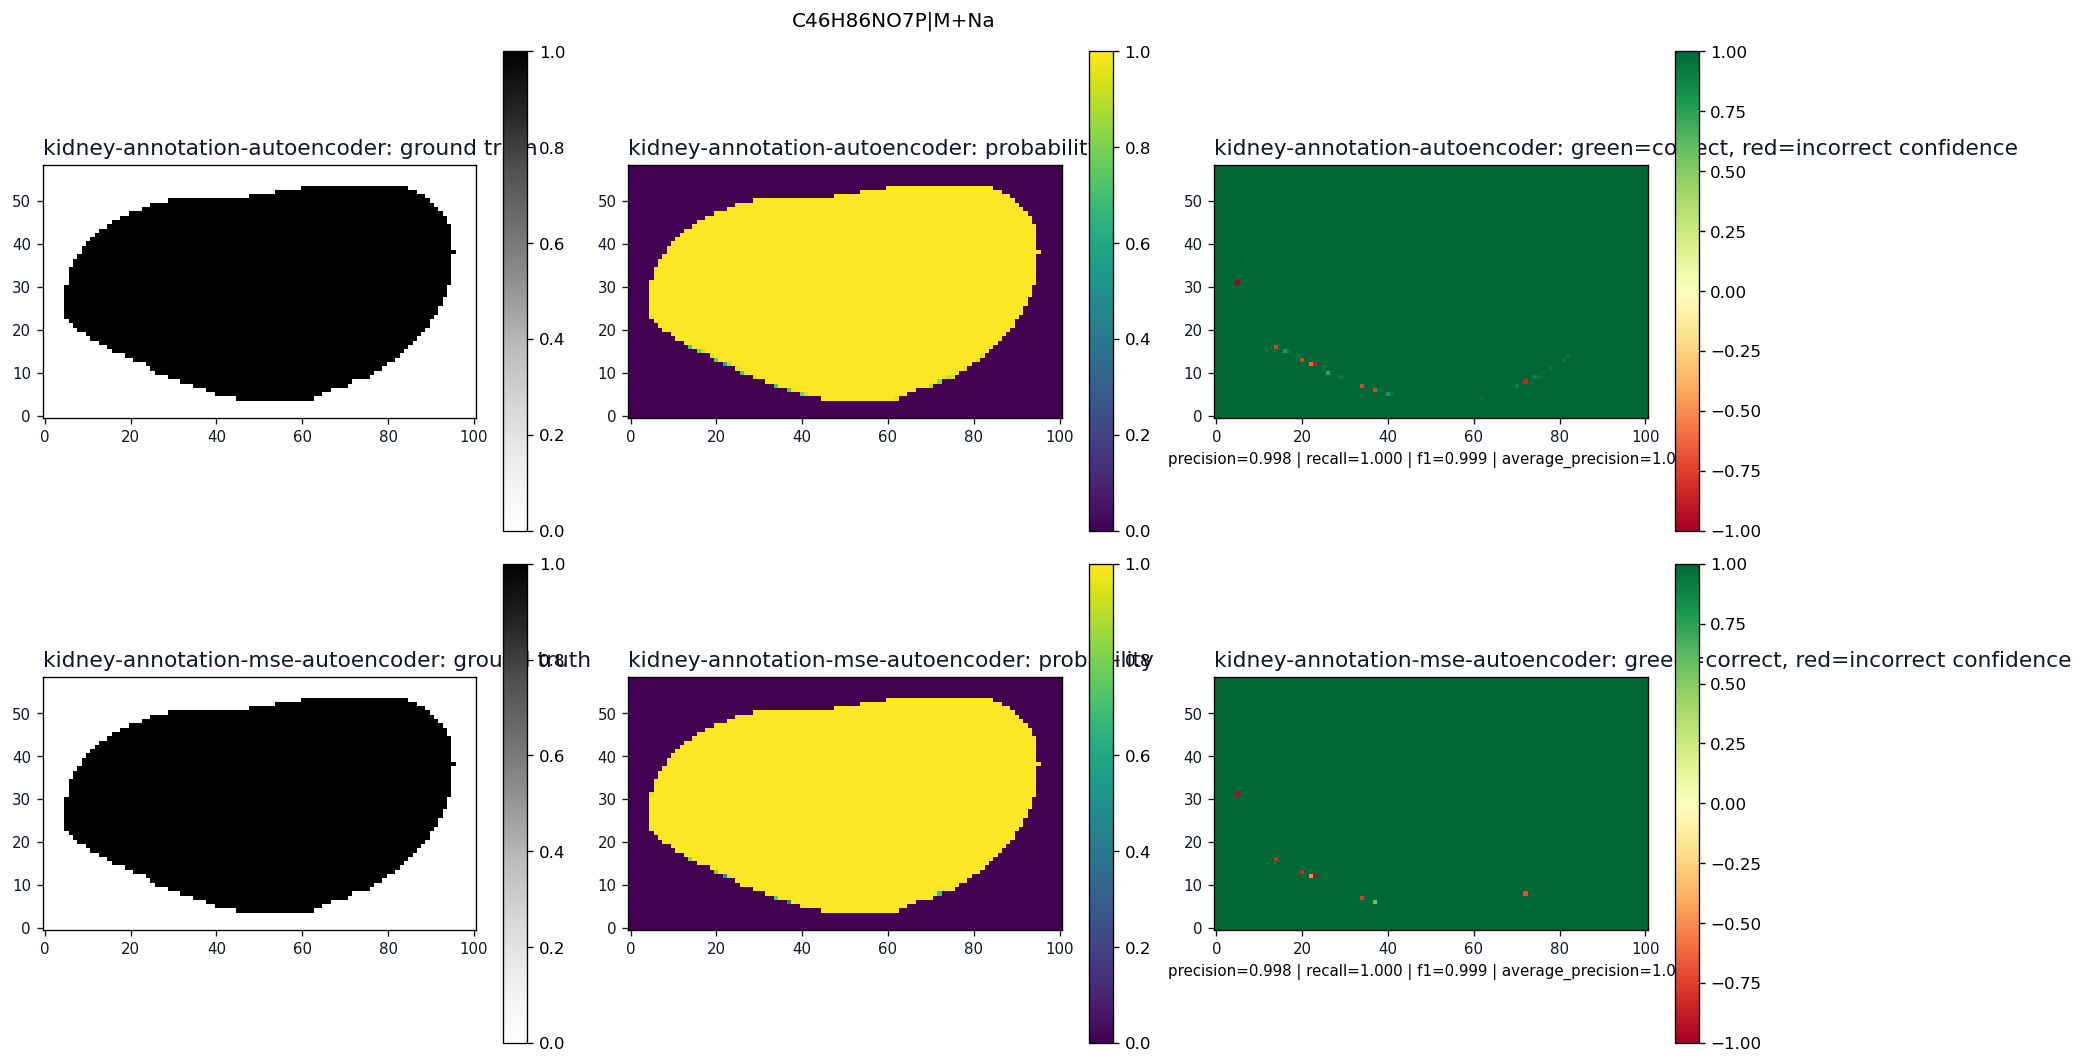

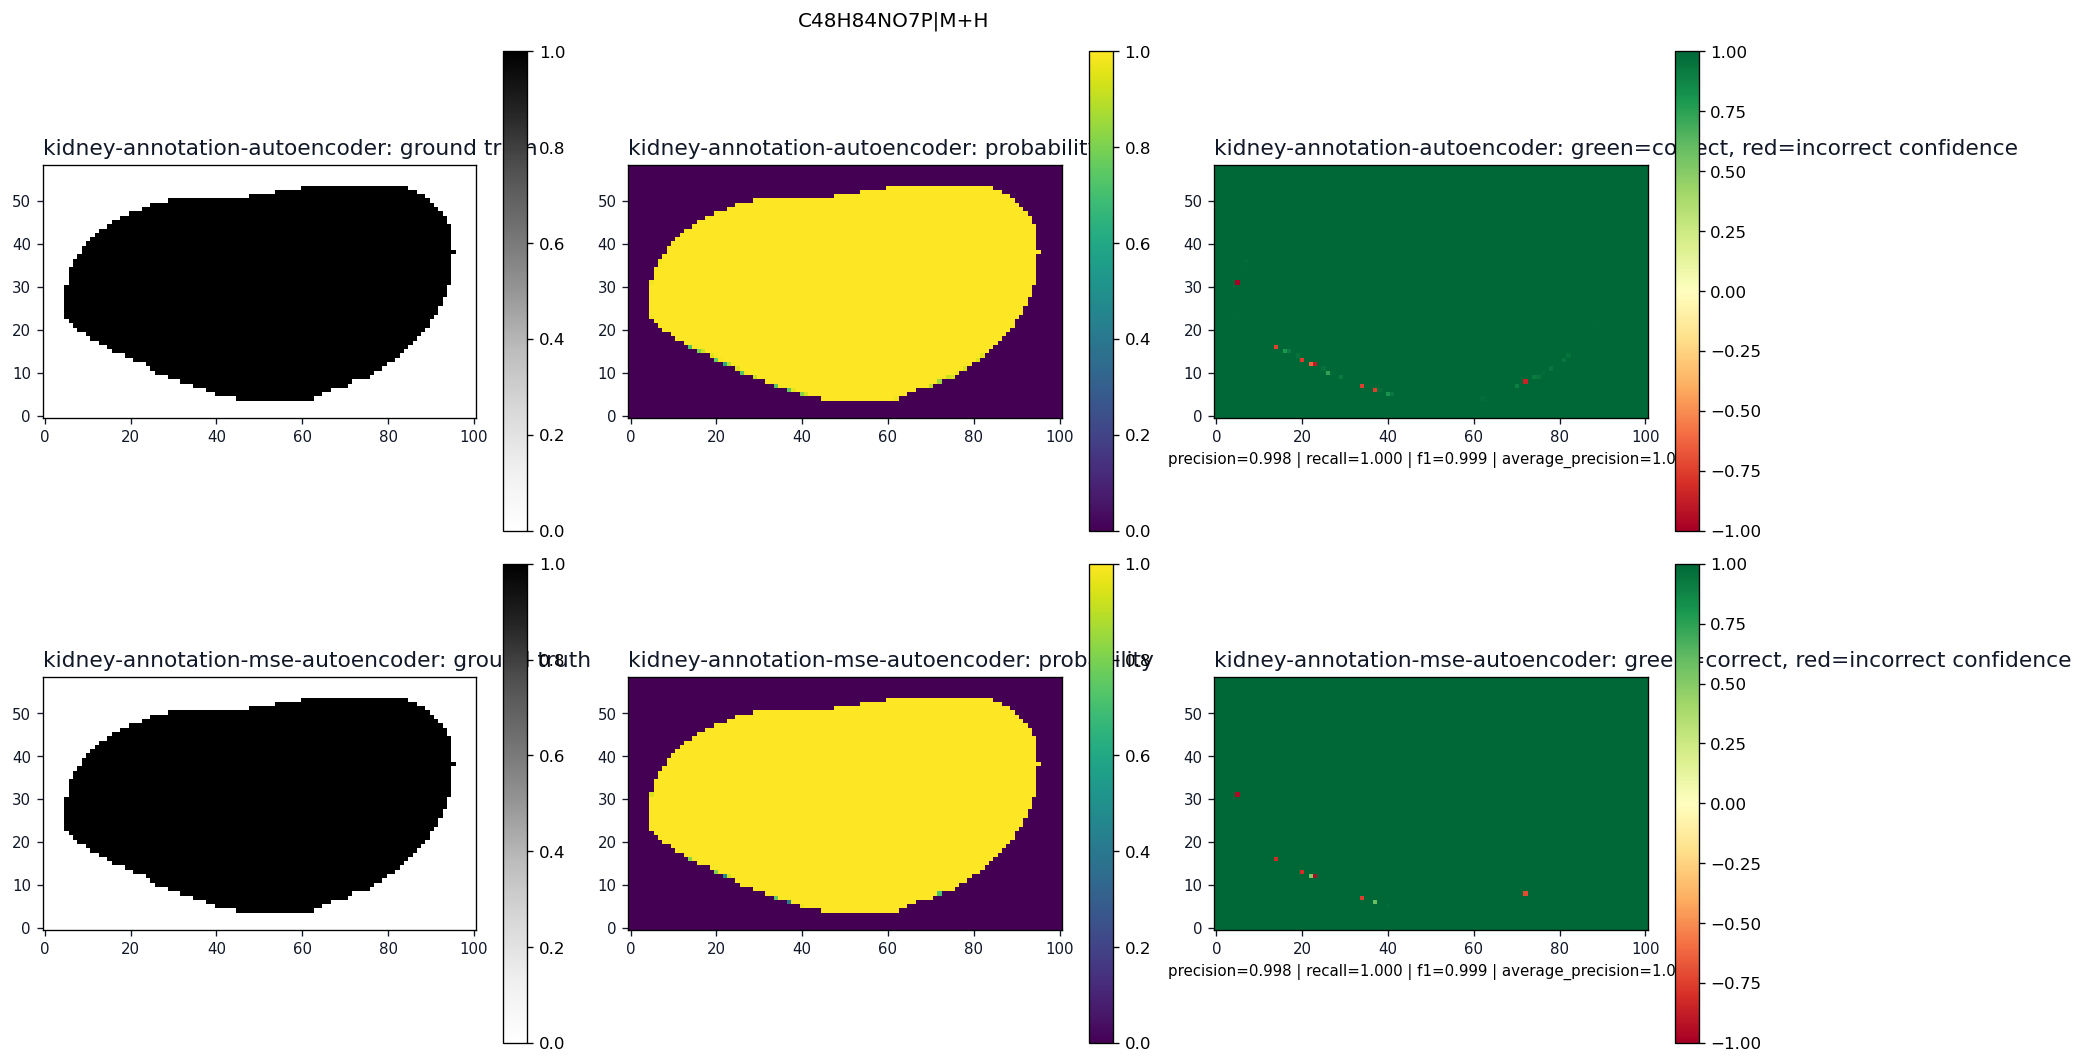

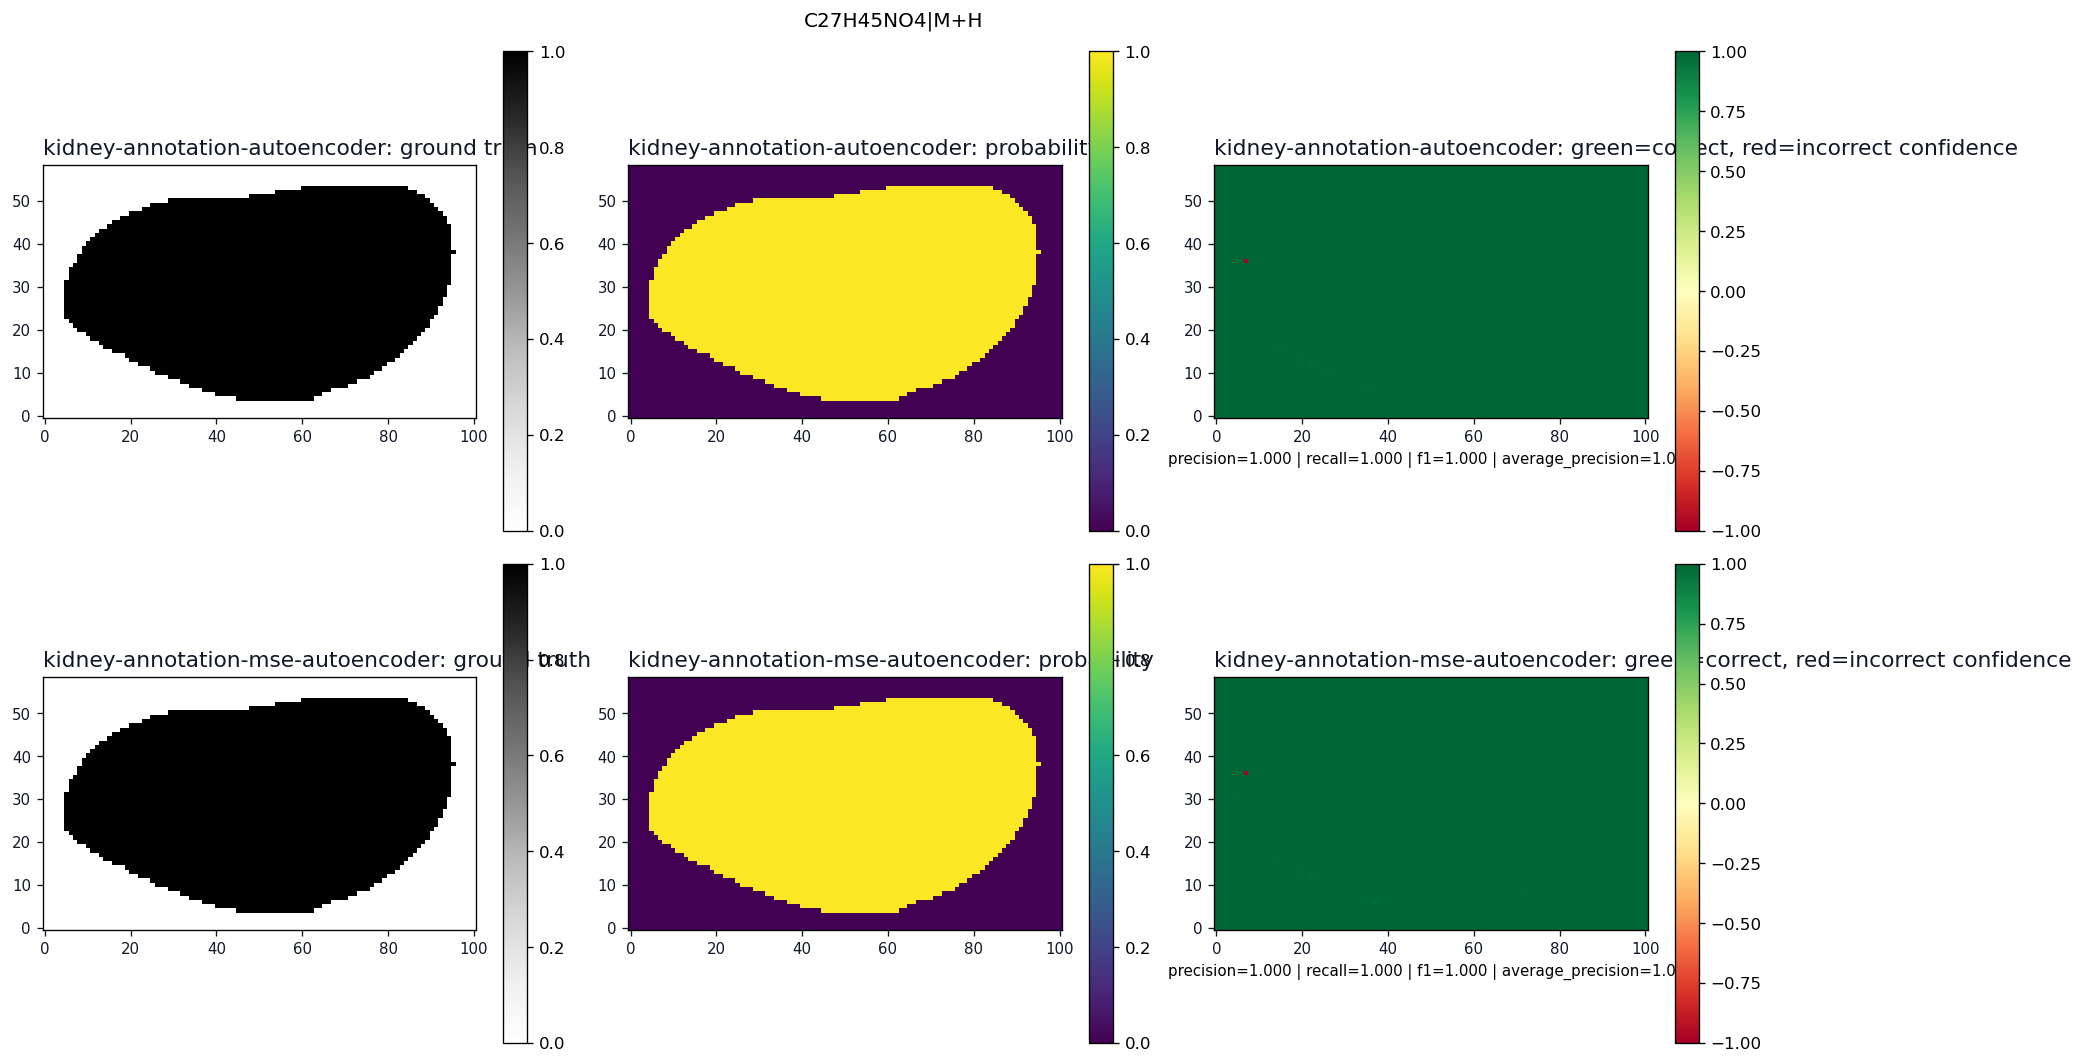

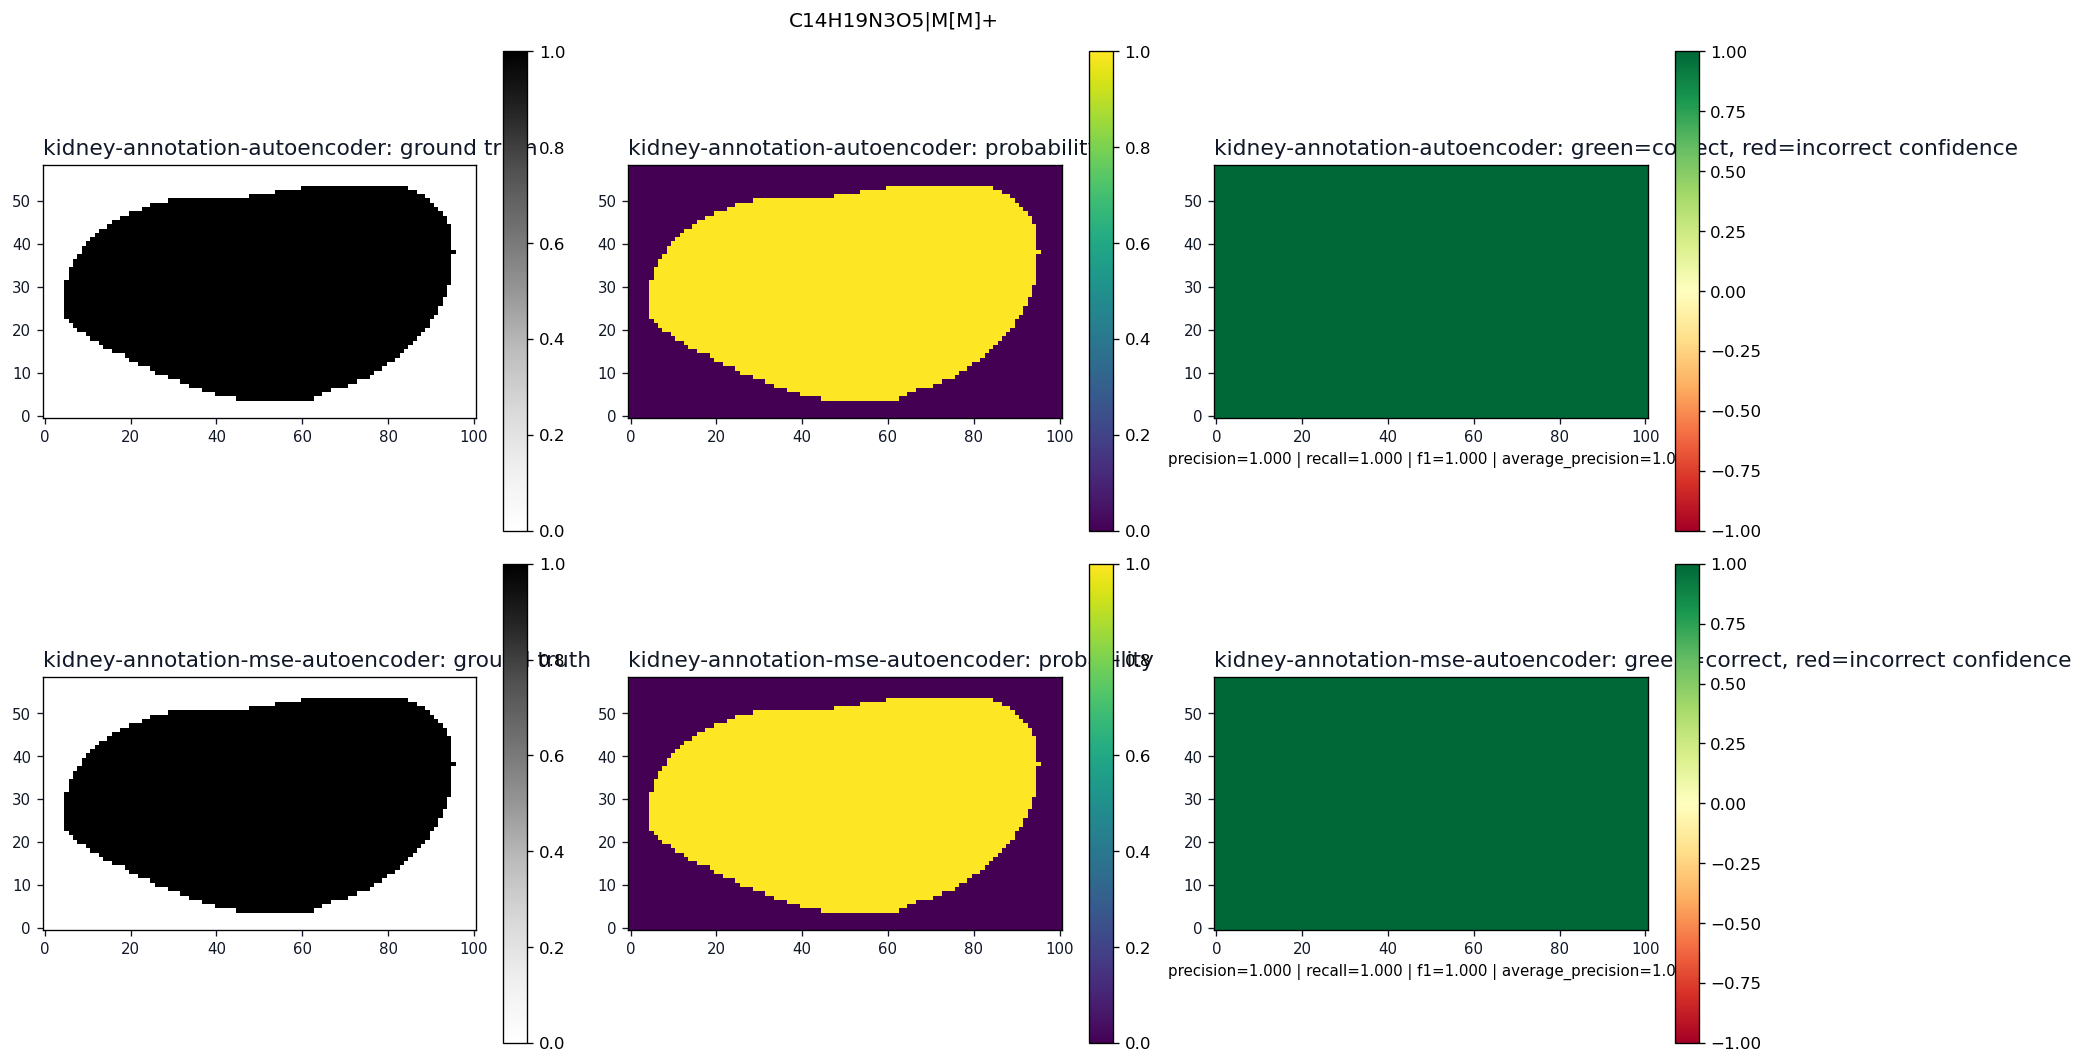

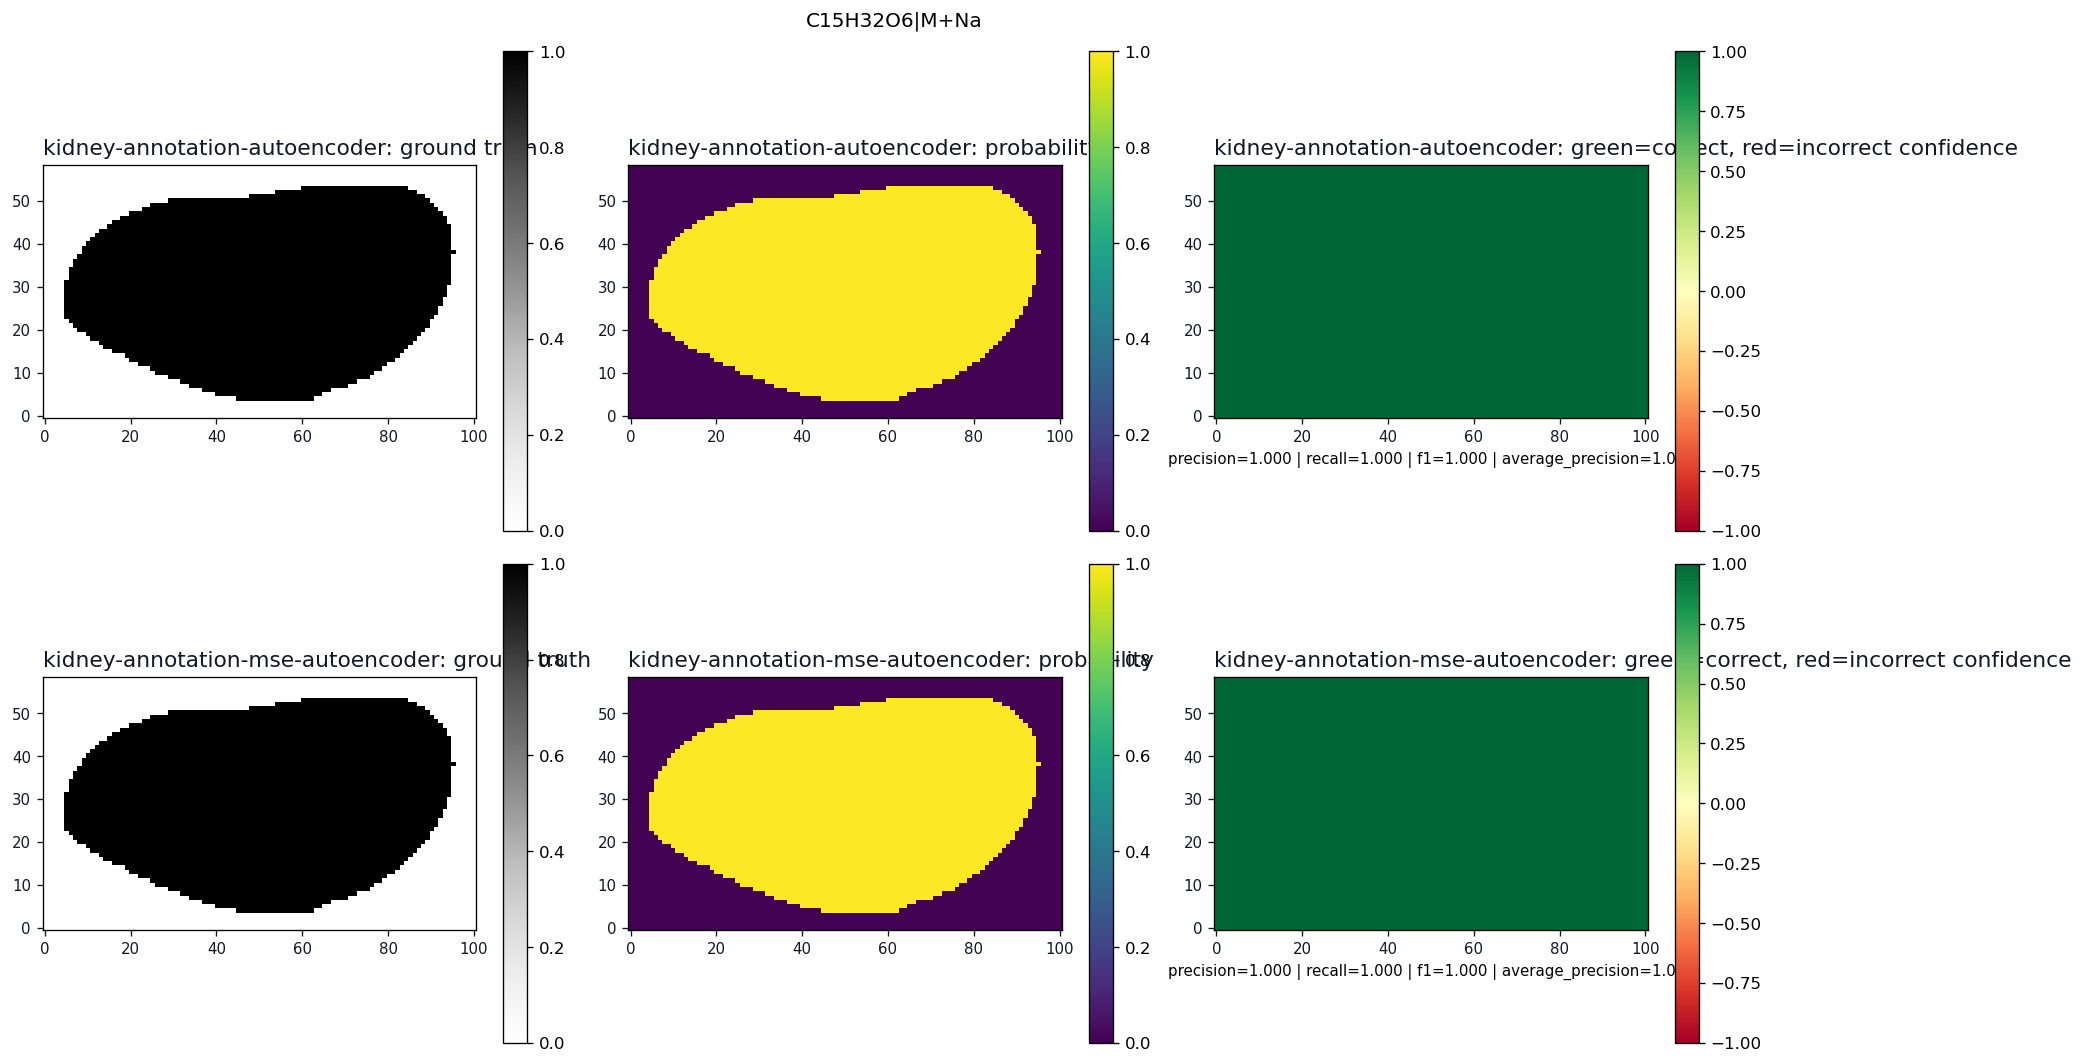

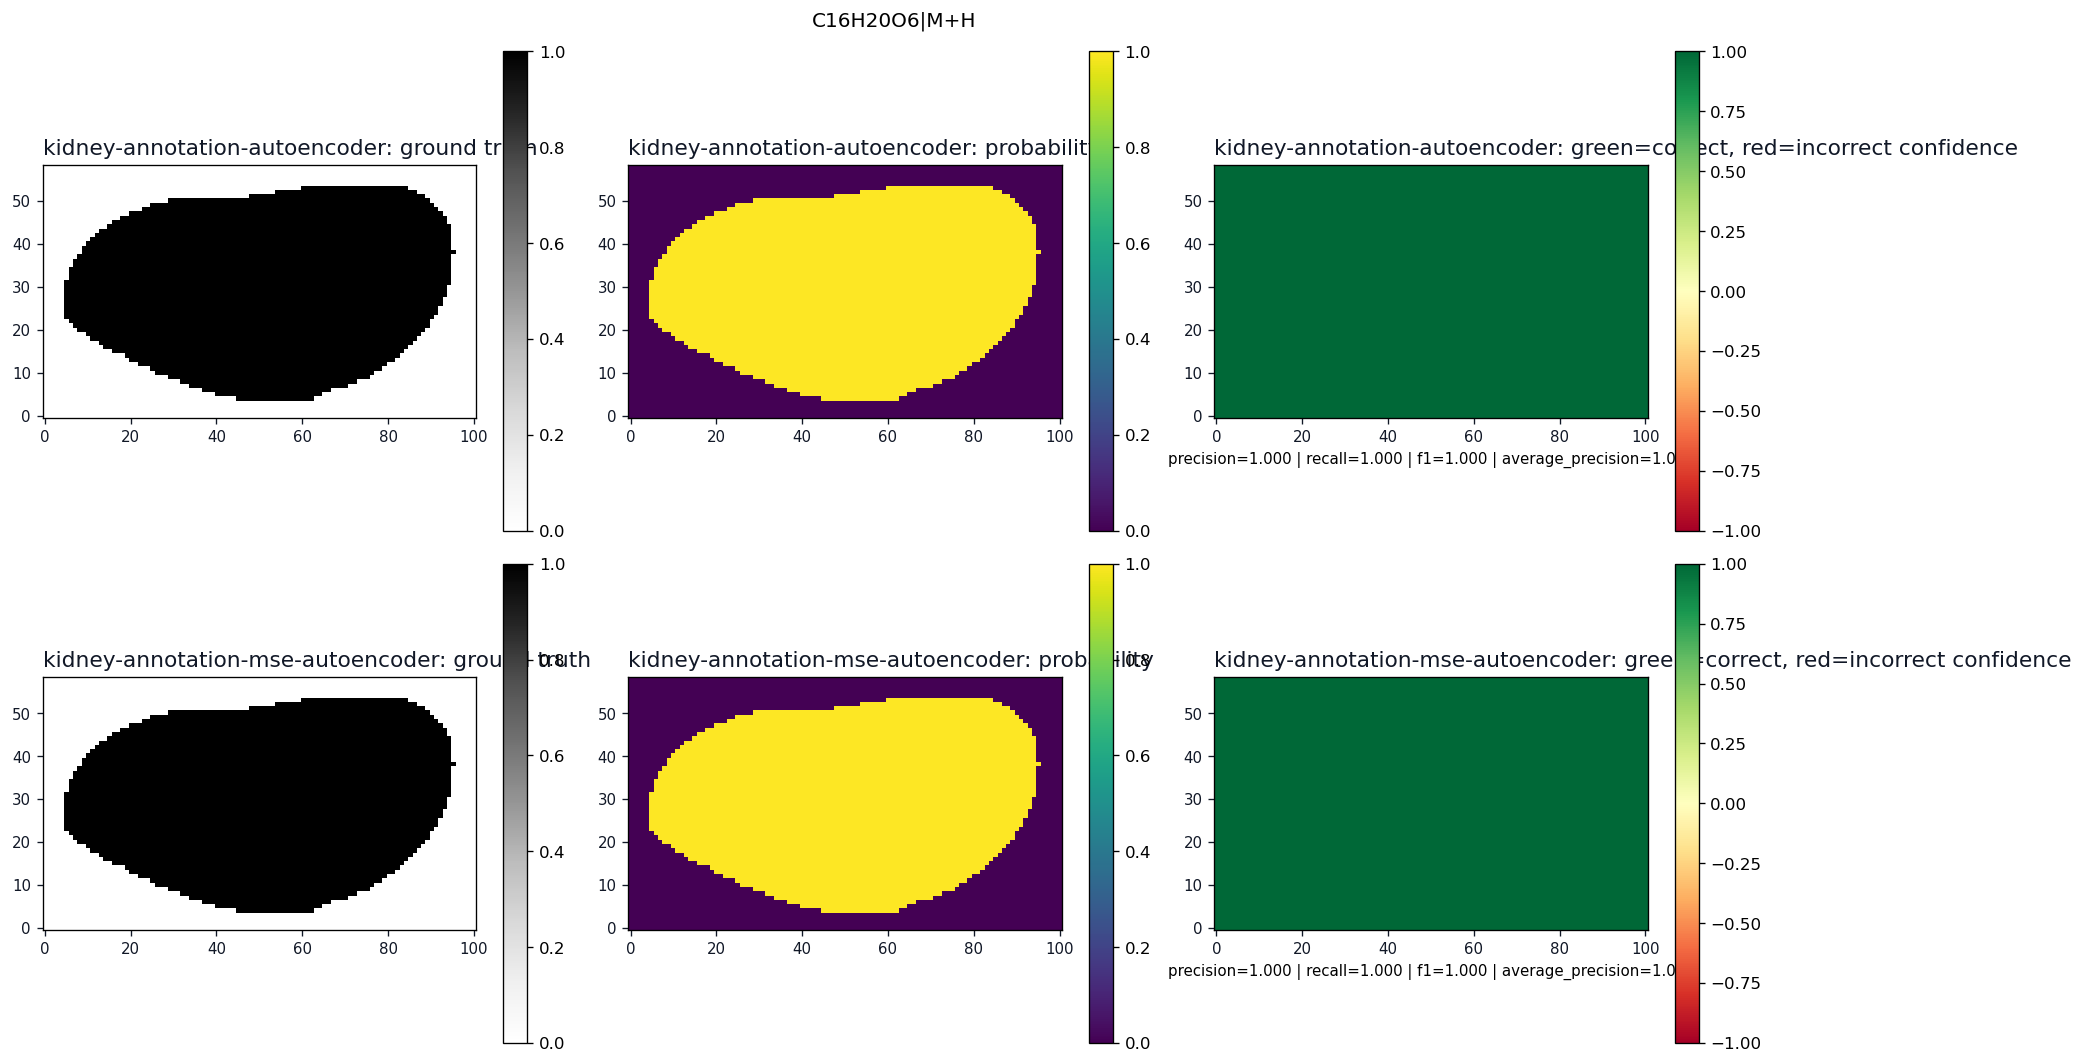

In [20]:
metrics_by_model = analysis.heads.class_metrics(HEAD_NAME, threshold=0.5)
weakest = sorted(metrics_by_model[MODEL_NAMES[0]], key=lambda row: row['f1'])[:6]
class_indices = [int(row['class_index']) for row in weakest]
analysis.heads.plot_class_overview(HEAD_NAME, class_indices, threshold=0.5)
{name: pd.DataFrame(values) for name, values in metrics_by_model.items()}